In [96]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "openai", "nest-asyncio", "python-dotenv", "openpyxl", 
    "pandas", "plotly", "matplotlib", "seaborn", "statsmodels", "tqdm", "numpy", "jinja2"
])

0

In [ ]:
import json
import os
import re
import unicodedata
import pandas as pd
import asyncio
import hashlib
import time
from pathlib import Path
import nest_asyncio
from openai import AsyncOpenAI
from dotenv import load_dotenv
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.notebook import tqdm
from tqdm import tqdm

Configuração da IA (LLM)

Setup para usar inteligência artificial na análise de documentos.

LLM: Inteligência artificial (modelo de linguagem) que consegue entender textos e responder perguntas sobre eles.

In [ ]:
modelo_openai = "gpt-4.1-mini"
MAX_CONCORRENTE = 15 # 15 apresenta varios erros
SALVAR_CACHE_A_CADA = 50

CACHE_PATH_ESCOPO = Path("./cache/escopo_classificacao.json")
CACHE_PATH_ESCOPO.parent.mkdir(exist_ok=True)

CACHE_PATH_IA_SEMANTICO = Path("./cache/extracao_campos_ia.json")
CACHE_PATH_IA_SEMANTICO.parent.mkdir(exist_ok=True)

Leitura dos Dados

Carregamento do arquivo CSV com informações dos processos e início da preparação dos dados.

In [71]:
# LINHA DE SELEÇÃO DO INPUT
df = pd.read_csv("dataset_curto.csv", encoding="utf-8") # 4s para carregar

def corrigir_mojibake(valor):
    if isinstance(valor, str) and ("Ã" in valor or "Â" in valor):
        try:
            return valor.encode("latin1").decode("utf-8")
        except UnicodeError:
            return valor
    return valor

colunas_texto = df.select_dtypes(include="object").columns
df[colunas_texto] = df[colunas_texto].apply(lambda col: col.map(corrigir_mojibake))

if "magistrado" in df.columns:
    df["magistrado"] = df["magistrado"].astype(str).str.strip().str.upper()

In [72]:
df.shape

(1000, 10)

Filtro 1: Processos que Mencionam o Itaú

O dataset fornecido pelo Itaú contém processos judiciais. Nem todos mencionam o banco.

Este filtro remove qualquer documento que não cite o Itaú em seu texto. É um filtro conservador: em caso de dúvida, mantemos o registro.

Dataset: conjunto de dados em formato de tabela.

In [73]:
# FILTRO — mantém apenas decisões com menção ao Itaú
pat_itau = re.compile(
    r'itaú|itau\s+unibanco|itaucard|banco\s+itau\s+consignado|itaú\s+unibanco',
    re.IGNORECASE
)

def menciona_itau(texto):
    if not isinstance(texto, str) or len(texto.strip()) == 0:
        return True  # conservador: mantém se texto ausente
    return bool(pat_itau.search(texto))

mask_itau = df["decisao"].apply(menciona_itau)
df_removidos = df[~mask_itau]
df = df[mask_itau].reset_index(drop=True)

print(f"✅ Filtro Itaú aplicado:")
print(f"  Mantidos : {len(df)}")
print(f"  Removidos: {len(df_removidos)}")

✅ Filtro Itaú aplicado:
  Mantidos : 979
  Removidos: 21


Filtro 2: Classificação em 3 Níveis de Confiança

Agora classificamos cada processo em 3 categorias:

- Nível 1 - Dentro (confiante): A sentença contém a decisão do juiz. O computador consegue identificar isso com precisão.

- Nível 2 - Incerto: Não encontramos padrão claro. Este processo será analisado pela inteligência artificial.

- Nível 3 - Fora (confiante): A sentença mostra que o processo foi encerrado sem julgamento de mérito. O computador identifica isso com precisão.

Ordem de verificação: primeiro procuramos por "Fora"; depois "Dentro"; se nada for encontrado, marcamos como "Incerto".

In [74]:
_PATTERNS_FORA = {
    "cumprimento_ou_execucao": re.compile(
        r"Classe\s*[-–]\s*Assunto\s*(Cumprimento de senten[çc]a|Execu[çc][aã]o)", re.IGNORECASE,
    ),
    "embargos_declaracao": re.compile(
        r"(embargos?\s+de\s+declara[çc][aã]o).{0,200}(nego\s+provimento|conhe[çc])",
        re.IGNORECASE | re.DOTALL,
    ),
    "incompetencia_territorial": re.compile(
        r"(reconhe[çc]o\s+a\s+incompet[êe]ncia|julgo\s+extinto.{0,300}incompet[êe]ncia)",
        re.IGNORECASE | re.DOTALL,
    ),
    "incapaz": re.compile(
        r"julgo\s+extinto.{0,300}(art\.?\s*8|incapaz)", re.IGNORECASE | re.DOTALL,
    ),
    "indefiro_inicial": re.compile(
        r"indefiro\s+a\s+inicial.{0,200}(julgo\s+extinto|extint)", re.IGNORECASE | re.DOTALL,
    ),
    "desistencia": re.compile(
        r"homologo.{0,200}desist[êe]ncia.{0,200}(extinto|extin[çc][aã]o)",
        re.IGNORECASE | re.DOTALL,
    ),
    "acordo": re.compile(
        r"homologo.{0,80}(acordo|transa[çc][aã]o).{0,200}extinto", re.IGNORECASE | re.DOTALL,
    ),
}

_PATTERNS_DENTRO = {
    "julgamento_merito": re.compile(
        r"julgo\s+(procedente|improcedente|parcialmente\s+procedente)", re.IGNORECASE,
    ),
}

def classificar_escopo_regex(texto: str) -> dict:
    for nome, padrao in _PATTERNS_FORA.items():
        if padrao.search(texto):
            return {"nivel": 3, "resultado": True, "motivo": nome}
    for nome, padrao in _PATTERNS_DENTRO.items():
        if padrao.search(texto):
            return {"nivel": 1, "resultado": False, "motivo": nome}
    return {"nivel": 2, "resultado": None, "motivo": "incerto"}

resultados = df["decisao"].fillna("").apply(classificar_escopo_regex)
df["nivel_confianca_regex"] = resultados.apply(lambda r: r["nivel"])
df["motivo_regex"] = resultados.apply(lambda r: r["motivo"])
df["classificacao_regex"] = resultados.apply(lambda r: r["resultado"])

dentro = (df["nivel_confianca_regex"] == 1).sum()
incerto = (df["nivel_confianca_regex"] == 2).sum()
fora = (df["nivel_confianca_regex"] == 3).sum()

print(f"✅ FASE 2 OK — Pré-filtro REGEX:")
print(f"  Nível 1 (DENTRO)  : {dentro:>3}")
print(f"  Nível 2 (Incerto) : {incerto:>3}")
print(f"  Nível 3 (FORA)    : {fora:>3}")

✅ FASE 2 OK — Pré-filtro REGEX:
  Nível 1 (DENTRO)  : 469
  Nível 2 (Incerto) : 356
  Nível 3 (FORA)    : 154


Filtro 3: Classificação dos Casos Incertos pela IA

Os casos marcados como "Incertos" serão analisados pela inteligência artificial.

O processamento usa técnicas para:
- Evitar processar o mesmo caso duas vezes (cache)
- Não sobrecarregar a API (limite de requisições simultâneas)
- Atuar de forma conservadora se houver falha

In [75]:
# ⚙️ FLAG DE CONTROLE: Se False, Nível 2 é considerado FORA sem análise LLM
ANALISAR_NIVEL_2_COM_LLM = True
print(f"⚙️  Flag ANALISAR_NIVEL_2_COM_LLM: {ANALISAR_NIVEL_2_COM_LLM}")

⚙️  Flag ANALISAR_NIVEL_2_COM_LLM: True


In [76]:
nest_asyncio.apply()

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("❌ OPENAI_API_KEY não definida. Adicione ao .env")

async_client = AsyncOpenAI(api_key=api_key)


def _carregar_cache():
    if CACHE_PATH_ESCOPO.exists():
        with open(CACHE_PATH_ESCOPO, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def _salvar_cache(cache):
    with open(CACHE_PATH_ESCOPO, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)

cache_local = _carregar_cache()
print(f"✅ Cache carregado: {len(cache_local)} entradas")
print(f"📍 Localização: {CACHE_PATH_ESCOPO.absolute()}")
print(f"⚙️  Flag ANALISAR_NIVEL_2_COM_LLM: {ANALISAR_NIVEL_2_COM_LLM}")

prompt_sistema = (
    "Você é um analista jurídico especializado em processos cíveis contra bancos brasileiros. "
    "Classifique decisões judiciais por escopo. Responda APENAS com JSON válido."
)

template_prompt = """Analise o documento judicial abaixo e classifique o ESCOPO.

PASSO 1 — TIPO DO DOCUMENTO
Classifique: "sentença" / "despacho" / "decisão interlocutória" / "outro"
Se não for sentença → retorne: {{"tipo_documento": "<valor>", "fora_do_escopo": true}}

PASSO 2 — TRIAGEM DE ESCOPO (apenas sentenças)
Retorne fora_do_escopo: true se QUALQUER uma das condições abaixo for verdadeira:

  A) EXTINÇÃO SEM ANÁLISE DO MÉRITO BANCÁRIO
     - Processo extinto por incompetência territorial ACOLHIDA pelo juiz
     - Processo extinto pois parte absolutamente incapaz não pode litigar em Juizado Especial
     - Processo extinto por superendividamento incompatível com rito do Juizado Especial
     - Processo extinto por inércia, abandono ou falta de pressuposto processual
     - Sentença que apenas homologa acordo/desistência SEM apreciar o mérito bancário

  B) MATÉRIA ALHEIA A SERVIÇOS BANCÁRIOS DO ITAÚ
     - Réu principal NÃO é banco (escola, hospital, construtora, etc.)
     - Ação trabalhista, de família/herança, previdenciária sem relação com banco

  C) DOCUMENTO NÃO É SENTENÇA DE MÉRITO
     - Despacho, decisão interlocutória, embargos de declaração, cumprimento de sentença

ATENÇÃO — NÃO confundir com fora do escopo:
  ✓ Incompetência ARGUIDA pela ré mas REJEITADA pelo juiz → DENTRO do escopo
  ✓ Menção à palavra "incompetência" sem extinção do processo → DENTRO do escopo

PASSO 3 — RESPOSTA
Se nenhuma condição acima se aplica: fora_do_escopo: false

Retorne exatamente este JSON:
{{"tipo_documento": "...", "fora_do_escopo": true/false}}

DOCUMENTO:
{decisao}"""

def _hash_decisao(texto):
    return hashlib.md5(texto[:500].strip().encode("utf-8")).hexdigest()

def _parse_json_seguro(conteudo):
    try:
        return json.loads(conteudo)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", conteudo, flags=re.DOTALL)
        if m:
            return json.loads(m.group(0))
        raise

# Rastreador de falhas para auditoria
falhas_llm = []

async def _chamar_llm_async(idx, texto, semaforo, max_tentativas=3):
    prompt = template_prompt.format(decisao=texto)
    async with semaforo:
        for tentativa in range(max_tentativas):
            try:
                resposta = await async_client.chat.completions.create(
                    model=modelo_openai,
                    messages=[
                        {"role": "system", "content": prompt_sistema},
                        {"role": "user", "content": prompt},
                    ],
                    response_format={"type": "json_object"},
                    temperature=0,
                )
                dados = _parse_json_seguro(resposta.choices[0].message.content.strip())
                return idx, bool(dados.get("fora_do_escopo", False))
            except Exception as e:
                if tentativa < max_tentativas - 1:
                    await asyncio.sleep(2 ** tentativa)
                else:
                    falhas_llm.append(idx)
                    print(f"⚠️  Falha idx={idx} após {max_tentativas} tentativas: {type(e).__name__}")
                    return idx, "FALHA_API_ESCOPO"

async def processar_nivel_2_async(indices_api, decisoes, resultados_final, usar_llm=True):
    """
    Processa nível 2 (incerto) com ou sem LLM.
    
    Args:
        usar_llm: Se True, chama LLM. Se False, classifica como FORA (True).
    """
    if not usar_llm:
        # Modo rápido: marcar todos como FORA (fora_do_escopo=True) sem chamar LLM
        for idx in indices_api:
            resultados_final[idx] = True  # FORA (fallback conservador)
        print(f"⚡ {len(indices_api)} casos Nível 2 marcados como FORA (sem LLM)")
        return
    
    # Modo normal: chamar LLM
    semaforo = asyncio.Semaphore(MAX_CONCORRENTE)
    tasks = [_chamar_llm_async(i, decisoes[i], semaforo) for i in indices_api]
    pendentes_flush = 0

    with tqdm(total=len(tasks), desc="🤖 Classificando Nível 2 (LLM)", unit="doc") as barra:
        for coro in asyncio.as_completed(tasks):
            idx, resultado = await coro
            resultados_final[idx] = resultado
            # Só salva no cache se não foi falha
            if resultado not in [None, "FALHA_API_ESCOPO"]:
                cache_local[_hash_decisao(decisoes[idx])] = resultado
                pendentes_flush += 1
                if pendentes_flush >= SALVAR_CACHE_A_CADA:
                    _salvar_cache(cache_local)
                    pendentes_flush = 0
            barra.update(1)
    
    if pendentes_flush > 0:
        _salvar_cache(cache_local)

print("✅ Fase 3 Setup: LLM async, cache, prompts prontos")

✅ Cache carregado: 402 entradas
📍 Localização: c:\Users\danil\clinicas26\cache\escopo_classificacao.json
⚙️  Flag ANALISAR_NIVEL_2_COM_LLM: True
✅ Fase 3 Setup: LLM async, cache, prompts prontos


In [77]:
# Processar APENAS Nível 2 (incertos) com LLM ou marcar como FORA
decisoes_lista = df["decisao"].fillna("").tolist()
indices_nivel_2 = df[df["nivel_confianca_regex"] == 2].index.tolist()
resultados_llm = [None] * len(df)
indices_a_processar = []

print(f"  Flag ANALISAR_NIVEL_2_COM_LLM: {'✅ ATIVO (com LLM)' if ANALISAR_NIVEL_2_COM_LLM else '❌ DESATIVO (marcar como FORA)'}")
print(f"  Total Nível 2: {len(indices_nivel_2)}")

if ANALISAR_NIVEL_2_COM_LLM:
    for idx in indices_nivel_2:
        texto = decisoes_lista[idx]
        hash_key = _hash_decisao(texto)
        resultado_em_cache = cache_local.get(hash_key)
        
        # Reprocessa se não existe OU se foi falha anterior
        if resultado_em_cache is None or resultado_em_cache == "FALHA_API_ESCOPO":
            indices_a_processar.append(idx)
        else:
            resultados_llm[idx] = resultado_em_cache
    
    print(f"  Cache hits: {len(indices_nivel_2) - len(indices_a_processar)}")
    print(f"  A processar: {len(indices_a_processar)}")
    
    if len(indices_a_processar) > 0:
        t_inicio = time.time()
        await processar_nivel_2_async(indices_a_processar, decisoes_lista, resultados_llm, usar_llm=True)
        tempo = time.time() - t_inicio
        print(f"✅ Concluído em {tempo:.1f}s")
    else:
        print("✅ Tudo no cache!")
else:
    await processar_nivel_2_async(indices_nivel_2, decisoes_lista, resultados_llm, usar_llm=False)

print(f"\n✅ OK: {sum(1 for x in resultados_llm if x is not None and x != 'FALHA_API_ESCOPO')} resultados processados")

  Flag ANALISAR_NIVEL_2_COM_LLM: ✅ ATIVO (com LLM)
  Total Nível 2: 356
  Cache hits: 356
  A processar: 0
✅ Tudo no cache!

✅ OK: 356 resultados processados


In [78]:
print(f"⚙️  Modo: {'LLM ativa' if ANALISAR_NIVEL_2_COM_LLM else 'Nível 2 → FORA (sem LLM)'}")
print()

df["fora_do_escopo_final"] = False
df["fonte_classificacao"] = None

mask_l1 = df["nivel_confianca_regex"] == 1
df.loc[mask_l1, "fora_do_escopo_final"] = False
df.loc[mask_l1, "fonte_classificacao"] = "REGEX_L1"

mask_l3 = df["nivel_confianca_regex"] == 3
df.loc[mask_l3, "fora_do_escopo_final"] = True
df.loc[mask_l3, "fonte_classificacao"] = "REGEX_L3"

mask_l2 = df["nivel_confianca_regex"] == 2
for idx, resultado in enumerate(resultados_llm):
    if resultado is not None:
        if resultado == "FALHA_API_ESCOPO":
            # Falhas vão para conservador (True) mas marcadas para auditoria
            df.loc[idx, "fora_do_escopo_final"] = True
            df.loc[idx, "fonte_classificacao"] = "FALHA_API_ESCOPO"
        else:
            df.loc[idx, "fora_do_escopo_final"] = resultado
            df.loc[idx, "fonte_classificacao"] = "LLM" if ANALISAR_NIVEL_2_COM_LLM else "FALLBACK_SEM_LLM"

l1_antes = (df['nivel_confianca_regex'] == 1).sum()
l2_antes = (df['nivel_confianca_regex'] == 2).sum()
l3_antes = (df['nivel_confianca_regex'] == 3).sum()

l2_depois_dentro = ((df['nivel_confianca_regex'] == 2) & (df['fora_do_escopo_final'] == False)).sum()
l2_depois_fora = ((df['nivel_confianca_regex'] == 2) & (df['fora_do_escopo_final'] == True)).sum()

depois_dentro = ((df['nivel_confianca_regex'] == 1) & (df['fora_do_escopo_final'] == False)).sum() + l2_depois_dentro
depois_fora = ((df['nivel_confianca_regex'] == 3) & (df['fora_do_escopo_final'] == True)).sum() + l2_depois_fora

print(f"📊 SUMÁRIO:")
print(f"  Nível 1 (DENTRO REGEX) : {l1_antes:>3}")
print(f"  Nível 2 (INCERTO)      : {l2_antes:>3}")
print(f"    → DENTRO (após proc) : {l2_depois_dentro:>3}")
print(f"    → FORA (após proc)   : {l2_depois_fora:>3}")
print(f"  Nível 3 (FORA REGEX)   : {l3_antes:>3}")
print(f"\n  TOTAL FINAL:")
print(f"    DENTRO: {depois_dentro:>3}")
print(f"    FORA:   {depois_fora:>3}")
print(f"    TOTAL:  {depois_dentro + depois_fora:>3}")

if ANALISAR_NIVEL_2_COM_LLM and len(falhas_llm) > 0:
    print(f"\n⚠️  Falhas na API: {len(falhas_llm)}")
    falhas_marcadas = (df['fonte_classificacao'] == 'FALHA_API_ESCOPO').sum()
    print(f"   Marcadas como FALHA_API_ESCOPO: {falhas_marcadas}")

⚙️  Modo: LLM ativa



📊 SUMÁRIO:
  Nível 1 (DENTRO REGEX) : 469
  Nível 2 (INCERTO)      : 356
    → DENTRO (após proc) :  36
    → FORA (após proc)   : 320
  Nível 3 (FORA REGEX)   : 154

  TOTAL FINAL:
    DENTRO: 505
    FORA:   474
    TOTAL:  979


In [79]:
# ── Retry automático para falhas do Nível 2 ──────────────────────────
MAX_RETRIES = 3

for tentativa_retry in range(MAX_RETRIES):
    indices_falha = [
        idx for idx, src in enumerate(df["fonte_classificacao"])
        if src == "FALHA_API_ESCOPO"
    ]
    
    if not indices_falha:
        print("✅ Nenhuma falha pendente.")
        break
    
    print(f"🔁 Retry {tentativa_retry + 1}/{MAX_RETRIES} — {len(indices_falha)} falhas pendentes...")
    await asyncio.sleep(10)  # espera antes de tentar
    await processar_nivel_2_async(indices_falha, decisoes_lista, resultados_llm, usar_llm=True)
    
    # Reaplicar resultados ao df
    for idx in indices_falha:
        resultado = resultados_llm[idx]
        if resultado is not None and resultado != "FALHA_API_ESCOPO":
            df.loc[idx, "fora_do_escopo_final"] = resultado
            df.loc[idx, "fonte_classificacao"] = "LLM_RETRY"

falhas_restantes = (df["fonte_classificacao"] == "FALHA_API_ESCOPO").sum()
print(f"\n{'✅ 0 falhas restantes!' if falhas_restantes == 0 else f'⚠️ Ainda restam {falhas_restantes} falhas.'}")

✅ Nenhuma falha pendente.

✅ 0 falhas restantes!


Extração de Campos usando Padrões de Texto (Regex)

Antes de usar a inteligência artificial, extraímos alguns campos usando padrões de texto. Isso funciona bem para informações que aparecem sempre da mesma forma:

- Resultado do julgamento (procedente ou improcedente)
- Tipo de processo
- Menção a gratuidade de justiça
- Menção a boletim de ocorrência
- Menção ao Reclame Aqui
- Repetição do débito

Essas informações vêm de termos técnicos padronizados ou aparecem sempre nas mesmas posições do documento (como o cabeçalho do TJSP), tornando a extração por padrão confiável e sem custo de API.

A extração é aplicada APENAS aos processos classificados como "Dentro" do escopo.

Regex: padrões de texto usados para procurar informações específicas (como procurar "julgo" para encontrar decisões).

In [80]:
_REGEX_CAMPOS = {

    # Aparece como campo standalone no cabeçalho: "\nJustiça Gratuita\n"
    # Também captura deferimento explícito no corpo da sentença
    # Ignora menções boilerplate do rodapé ("Ressalvada a hipótese de gratuidade...")
    "justica_gratuita": re.compile(
        r"\nJustiça\s+Gratuita\s*\n"
        r"|[Dd]eferida\s+a\s+gratuidade"
        r"|[Mm]antenho\s+.{0,30}(gratuidade|benefícios\s+da\s+(AJG|assistência))"
        r"|gratuidade\s+(da\s+justiça|processual)\s+(deferida|concedida|foi\s+deferida)"
        r"|A\s+gratuidade\s+foi\s+deferida",
        re.IGNORECASE,
    ),

    # Cabeçalho padronizado do TJSP
    "rito_juizado_especial": re.compile(
        r"Procedimento\s+do\s+Juizado\s+Especial|Juizado\s+Especial\s+C[íi]vel",
        re.IGNORECASE,
    ),

    # Fórmula jurídica rígida — dispositivo da sentença
    # Exclui "procedente em parte" (= parcialmente procedente, fórmula usada no Juizado)
    "resultado_procedente": re.compile(
        r"julgo\s+procedente(?!\s+em\s+parte|\s+a\s+execu|\s+o\s+pedido\s+de\s+extin)",
        re.IGNORECASE,
    ),
    "resultado_improcedente": re.compile(
        r"julgo\s+improcedente",
        re.IGNORECASE,
    ),
    "resultado_parcialmente_procedente": re.compile(
        r"julgo\s+parcialmente\s+procedente"
        r"|julgo\s+procedente\s+em\s+parte",
        re.IGNORECASE,
    ),

    # Termos técnicos inequívocos
    "boletim_ocorrencia": re.compile(
        r"boletim\s+de\s+ocorr[êe]ncia|b\.o\.|registro\s+policial",
        re.IGNORECASE,
    ),
    "mencao_reclame_aqui": re.compile(
        r"reclame\s+aqui",
        re.IGNORECASE,
    ),

    # Repetição do indébito — art. 42 CDC
    "repeticao_dobro": re.compile(
        r"devolução\s+em\s+dobro"
        r"|repetição\s+do\s+indébito\s+em\s+dobro"
        r"|restituição\s+em\s+dobro"
        r"|em\s+dobro.{0,60}art\.?\s*42",
        re.IGNORECASE,
    ),
    "repeticao_simples": re.compile(
        r"repetição\s+do\s+indébito(?!\s+em\s+dobro)"
        r"|restituição\s+simples",
        re.IGNORECASE,
    ),
}


def extrair_campos_regex(texto: str) -> dict:
    jg = bool(_REGEX_CAMPOS["justica_gratuita"].search(texto))

    # Testa parcialmente procedente ANTES de procedente (evita captura parcial)
    if _REGEX_CAMPOS["resultado_parcialmente_procedente"].search(texto):
        resultado = "parcialmente procedente"
    elif _REGEX_CAMPOS["resultado_procedente"].search(texto):
        resultado = "procedente"
    elif _REGEX_CAMPOS["resultado_improcedente"].search(texto):
        resultado = "improcedente"
    else:
        resultado = "não identificado"

    if _REGEX_CAMPOS["rito_juizado_especial"].search(texto):
        rito = "Juizado Especial"
    else:
        rito = "Procedimento Comum"

    if _REGEX_CAMPOS["repeticao_dobro"].search(texto):
        repeticao = "dobro"
    elif _REGEX_CAMPOS["repeticao_simples"].search(texto):
        repeticao = "simples"
    else:
        repeticao = "não aplicável"

    return {
        "justica_gratuita_regex":     "sim" if jg else "não",
        "rito_processual_regex":      rito,
        "resultado_julgamento_regex": resultado,
        "boletim_ocorrencia_regex":   "sim" if _REGEX_CAMPOS["boletim_ocorrencia"].search(texto) else "não",
        "mencao_reclame_aqui_regex":  "sim" if _REGEX_CAMPOS["mencao_reclame_aqui"].search(texto) else "não",
        "repeticao_indebito_regex":   repeticao,
    }


# Aplica apenas nos casos dentro do escopo
mask_dentro = df["fora_do_escopo_final"] == False
campos_extraidos = df.loc[mask_dentro, "decisao"].fillna("").apply(extrair_campos_regex)
df_campos = pd.DataFrame(list(campos_extraidos), index=campos_extraidos.index)

for col in df_campos.columns:
    df[col] = None
    df.loc[mask_dentro, col] = df_campos[col]

print(f"✅ Campos extraídos para {mask_dentro.sum()} casos dentro do escopo:")
for col in df_campos.columns:
    n = (df[col].notna()).sum()
    print(f"  {col}: {n} preenchidos")

print()
print(df.loc[mask_dentro, ["decisao"] + list(df_campos.columns)].head(3).to_string())

✅ Campos extraídos para 505 casos dentro do escopo:
  justica_gratuita_regex: 505 preenchidos
  rito_processual_regex: 505 preenchidos
  resultado_julgamento_regex: 505 preenchidos
  boletim_ocorrencia_regex: 505 preenchidos
  mencao_reclame_aqui_regex: 505 preenchidos
  repeticao_indebito_regex: 505 preenchidos

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [81]:
# Garante que as colunas existam antes de filtrar
df_dentro = df[df["fora_do_escopo_final"] == False].copy()

# Reaplica extração se necessário
if "resultado_julgamento_regex" not in df_dentro.columns:
    campos_extraidos = df_dentro["decisao"].fillna("").apply(extrair_campos_regex)
    df_campos = pd.DataFrame(list(campos_extraidos), index=campos_extraidos.index)
    df_dentro = pd.concat([df_dentro, df_campos], axis=1)

Extração de Campos que Precisam de Interpretação (por IA)

Alguns campos requerem entender o contexto e significado do texto:

- Tipo de ação (qual o motivo da ação: cobrança, consumidor, etc)
- Contato prévio com o banco
- Canal de contato (SAC, Procon, Reclame Aqui, etc)
- Culpa atribuída
- Valores de indenização

A inteligência artificial analisa esses campos para casos que estão dentro do escopo.

O processamento é automático, com proteções para não sobrecarregar a API.

In [82]:
def _carregar_cache_ia():
    if CACHE_PATH_IA_SEMANTICO.exists():
        with open(CACHE_PATH_IA_SEMANTICO, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def _salvar_cache_ia(cache):
    with open(CACHE_PATH_IA_SEMANTICO, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)

cache_ia = _carregar_cache_ia()
print(f"✅ Cache IA carregado: {len(cache_ia)} entradas")

# %%
prompt_sistema_ia = (
    "Você é um analista jurídico especializado em processos cíveis contra bancos brasileiros. "
    "Extraia informações estruturadas de decisões judiciais em português. "
    "Responda APENAS com JSON válido, sem texto adicional."
)

template_prompt_ia = """Analise o documento judicial abaixo e extraia as variáveis indicadas.

════════════════════════════════════════
EXTRAÇÃO DE CAMPOS SEMÂNTICOS
════════════════════════════════════════
O documento já foi classificado como sentença dentro do escopo.
Extraia APENAS os campos abaixo — não reclassifique o escopo.

  1. tipo_acao — escolha UMA categoria:
     - "empréstimo não reconhecido": autor nega ter contratado empréstimo consignado ou pessoal
     - "fraude em conta ou cartão": golpe, transação não autorizada (motoboy, falsa central,
       PIX fraudulento, clonagem, "boa noite Cinderela", invasão de conta via engenharia social)
     - "revisão contratual": autor questiona taxas, juros ou cláusulas de contrato que RECONHECE ter firmado
     - "cobrança indevida": cobrança de tarifa, serviço, seguro ou parcela não contratada
     - "superendividamento": pedido de repactuação com base na Lei 14.181/2021
     - "outro": não se encaixa em nenhuma categoria acima

2. contato_previo_banco: "sim" / "não"
     Retorne "sim" SOMENTE se o texto menciona EXPLICITAMENTE que o autor
     contatou o banco com objetivo de reclamar ou resolver o problema,
     ANTES de decidir processar judicialmente.

     EXIGIDO para retornar "sim":
       - O texto deve conter palavras como: "SAC", "ouvidoria", "agência",
         "Procon", "Reclame Aqui", "reclamação", "ligou", "compareceu",
         "tentou resolver", "buscou o banco", "protocolo de atendimento"
       - O contato deve ser ANTERIOR ao ajuizamento e com intenção de
         resolver o problema, não apenas de comunicar o evento

     NÃO retorne "sim" se:
       - O contato foi para comunicar fraude/golpe já ocorrido
         (ex: ligar para cancelar cartão, registrar B.O., bloquear conta)
       - O texto não menciona explicitamente nenhum canal de contato
       - Há dúvida sobre se o contato foi antes ou depois do problema
       - O único "contato" mencionado é o próprio ajuizamento da ação

     Se o texto não mencionar explicitamente nenhum canal → retorne "não".

  3. canal_contato: "SAC" / "Ouvidoria" / "Procon" / "Reclame Aqui" / "Agência" / "não identificado"
     Retorne o canal mencionado EXPLICITAMENTE como meio de contato prévio ao ajuizamento.
     Se múltiplos canais: retorne o primeiro/principal mencionado.
     Se contato_previo_banco = "não" → retorne "não identificado".

  4. culpa_atribuida: "banco" / "consumidor" / "terceiro" / "compartilhada" / "não identificado"
     Regras de inferência:
     - procedente ou parcialmente procedente → "banco"
       (salvo texto indicar terceiro ou compartilhada)
     - improcedente SEM menção a fraude → "consumidor"
     - improcedente COM reconhecimento de fraude por terceiro
       mas sem responsabilidade do banco → "terceiro"
     - improcedente onde juiz reconhece fraude mas absolve banco
       por ausência de falha → "terceiro"
     - extinto → "não identificado"

  5. valor_danos_morais: número decimal em reais
     - Valor CONDENADO na sentença (não o pedido da inicial)
     - 0.0 = não houve condenação por danos morais
     - -1.0 = condenado mas valor a apurar em liquidação de sentença

  6. valor_danos_materiais: número decimal em reais
     - Valor CONDENADO na sentença (não o pedido da inicial)
     - Inclui: restituição, devolução, ressarcimento, repetição do indébito
       (simples ou em dobro), reembolso de valores descontados indevidamente
     - 0.0 = não houve condenação por danos materiais
     - -1.0 = condenado mas valor a apurar em liquidação
     ATENÇÃO: se condenado à repetição em dobro, some os valores
     e retorne o total condenado, não o valor original.

REGRAS GERAIS:
  - Nunca infira o que não está escrito. Em caso de dúvida → "não identificado" ou "não".
  - O valor relevante é SEMPRE o condenado, nunca o pedido da parte autora.
  - Quando a sentença julgar múltiplos contratos com resultados diferentes → use o resultado majoritário.

Retorne exatamente este JSON (sem texto antes ou depois):
{{"tipo_acao":"...","contato_previo_banco":"...","canal_contato":"...","culpa_atribuida":"...","valor_danos_morais":0.0,"valor_danos_materiais":0.0}}

════════════════════════════════════════
DOCUMENTO:
════════════════════════════════════════
{decisao}"""

_campos_padrao_ia = {
    "tipo_acao":            "não identificado",
    "contato_previo_banco": "não",
    "canal_contato":        "não identificado",
    "culpa_atribuida":      "não identificado",
    "valor_danos_morais":   0.0,
    "valor_danos_materiais": 0.0,
}

falhas_ia = []

async def _chamar_ia_async(idx, texto, semaforo, max_tentativas=3):
    prompt = template_prompt_ia.format(decisao=texto)
    async with semaforo:
        for tentativa in range(max_tentativas):
            try:
                resposta = await async_client.chat.completions.create(
                    model=modelo_openai,
                    messages=[
                        {"role": "system", "content": prompt_sistema_ia},
                        {"role": "user", "content": prompt},
                    ],
                    response_format={"type": "json_object"},
                    temperature=0,
                )
                dados = _parse_json_seguro(resposta.choices[0].message.content.strip())

                # Garante tipos numéricos corretos
                for campo in ("valor_danos_morais", "valor_danos_materiais"):
                    try:
                        dados[campo] = float(dados.get(campo) or 0.0)
                    except (ValueError, TypeError):
                        dados[campo] = 0.0

                resultado = {**_campos_padrao_ia, **dados}
                resultado["status_extracao"] = "ok"
                return idx, resultado

            except Exception as e:
                is_rate_limit = "429" in str(e) or "RateLimitError" in type(e).__name__
                if tentativa < max_tentativas - 1:
                    espera = (2 ** tentativa) * 10 if is_rate_limit else 2 ** tentativa
                    await asyncio.sleep(espera)
                else:
                    falhas_ia.append(idx)
                    print(f"⚠️  Falha idx={idx} após {max_tentativas} tentativas: {type(e).__name__}")
                    fallback = {**_campos_padrao_ia, "status_extracao": "falha_api"}
                    return idx, fallback

async def processar_ia_async(indices_api, decisoes, resultados_final):
    semaforo = asyncio.Semaphore(MAX_CONCORRENTE)
    tasks = [_chamar_ia_async(i, decisoes[i], semaforo) for i in indices_api]
    pendentes_flush = 0

    with tqdm(total=len(tasks), desc="🤖 Extraindo campos (IA)", unit="doc") as barra:
        for coro in asyncio.as_completed(tasks):
            idx, resultado = await coro
            resultados_final[idx] = resultado
            cache_ia[_hash_decisao(decisoes[idx])] = resultado
            pendentes_flush += 1
            if pendentes_flush >= SALVAR_CACHE_A_CADA:
                _salvar_cache_ia(cache_ia)
                pendentes_flush = 0
            barra.update(1)

    if pendentes_flush > 0:
        _salvar_cache_ia(cache_ia)

print("✅ Setup extração IA pronto")

✅ Cache IA carregado: 503 entradas
✅ Setup extração IA pronto


In [83]:
# Processa apenas casos dentro do escopo
decisoes_lista = df["decisao"].fillna("").tolist()
indices_dentro = df[df["fora_do_escopo_final"] == False].index.tolist()
resultados_ia = [None] * len(df)
indices_a_processar_ia = []

for idx in indices_dentro:
    hash_key = _hash_decisao(decisoes_lista[idx])
    resultado_cache = cache_ia.get(hash_key)
    # Reprocessa se não existe OU se foi falha anterior
    if resultado_cache is None or resultado_cache.get("status_extracao") == "falha_api":
        indices_a_processar_ia.append(idx)
    else:
        resultados_ia[idx] = resultado_cache

print(f"📊 Extração IA — campos semânticos:")
print(f"  Total dentro do escopo : {len(indices_dentro)}")
print(f"  Cache hits             : {len(indices_dentro) - len(indices_a_processar_ia)}")
print(f"  A processar            : {len(indices_a_processar_ia)}")

if len(indices_a_processar_ia) > 0:
    t_inicio = time.time()
    await processar_ia_async(indices_a_processar_ia, decisoes_lista, resultados_ia)
    tempo = time.time() - t_inicio
    print(f"✅ Concluído em {tempo:.1f}s | Falhas: {len(falhas_ia)}")
else:
    print("✅ Tudo no cache!")

📊 Extração IA — campos semânticos:
  Total dentro do escopo : 505
  Cache hits             : 505
  A processar            : 0
✅ Tudo no cache!


In [84]:
# Adiciona colunas _ia ao df — status_extracao tratado separadamente
for campo in _campos_padrao_ia:
    df[f"{campo}_ia"] = None

df["status_extracao_ia"] = None

for idx, resultado in enumerate(resultados_ia):
    if resultado is not None:
        for campo, valor in resultado.items():
            if campo != "status_extracao":  # status_extracao não vira coluna _ia
                df.loc[idx, f"{campo}_ia"] = valor
        df.loc[idx, "status_extracao_ia"] = resultado.get("status_extracao", "ok")

campos_ia = [f"{c}_ia" for c in _campos_padrao_ia] + ["status_extracao_ia"]
n_preenchidos = df[campos_ia[0]].notna().sum()
print(f"✅ Campos IA adicionados: {n_preenchidos} casos preenchidos")
print()
for col in campos_ia:
    print(f"  {col}: {df[col].notna().sum()} preenchidos")

if df["status_extracao_ia"].notna().any():
    print()
    status_counts = df["status_extracao_ia"].value_counts()
    for status, count in status_counts.items():
        print(f"  {status}: {count}")

✅ Campos IA adicionados: 505 casos preenchidos

  tipo_acao_ia: 505 preenchidos
  contato_previo_banco_ia: 505 preenchidos
  canal_contato_ia: 505 preenchidos
  culpa_atribuida_ia: 505 preenchidos
  valor_danos_morais_ia: 505 preenchidos
  valor_danos_materiais_ia: 505 preenchidos
  status_extracao_ia: 505 preenchidos

  ok: 505


In [85]:
# Aliases: campos extraídos via regex disponibilizados com sufixo _ia
# para compatibilidade com as células de EDA e modelo inferencial.
# boletim_ocorrencia_regex não tem o "_de_" que o restante do código espera.
df['resultado_julgamento_ia']   = df['resultado_julgamento_regex']
df['rito_processual_ia']        = df['rito_processual_regex']
df['justica_gratuita_ia']       = df['justica_gratuita_regex']
df['mencao_reclame_aqui_ia']    = df['mencao_reclame_aqui_regex']
df['boletim_de_ocorrencia_ia']  = df['boletim_ocorrencia_regex']

In [86]:
# ── Retry automático para falhas da extração IA ──────────────────────
MAX_RETRIES_IA = 3

for tentativa_retry in range(MAX_RETRIES_IA):
    indices_falha_ia = [
        idx for idx, resultado in enumerate(resultados_ia)
        if resultado is not None and resultado.get("status_extracao") == "falha_api"
    ]
    
    if not indices_falha_ia:
        print("✅ Nenhuma falha pendente na extração IA.")
        break
    
    print(f"🔁 Retry {tentativa_retry + 1}/{MAX_RETRIES_IA} — {len(indices_falha_ia)} falhas pendentes...")
    await asyncio.sleep(30)  # espera maior — RateLimitError precisa de mais tempo
    await processar_ia_async(indices_falha_ia, decisoes_lista, resultados_ia)
    
    # Reaplicar resultados ao df
    for idx in indices_falha_ia:
        resultado = resultados_ia[idx]
        if resultado is not None and resultado.get("status_extracao") == "ok":
            for campo, valor in resultado.items():
                if campo != "status_extracao":
                    df.loc[idx, f"{campo}_ia"] = valor
            df.loc[idx, "status_extracao_ia"] = "ok"
            # Atualiza aliases _regex → _ia
            df.loc[idx, 'resultado_julgamento_ia']  = df.loc[idx, 'resultado_julgamento_regex']
            df.loc[idx, 'rito_processual_ia']       = df.loc[idx, 'rito_processual_regex']
            df.loc[idx, 'justica_gratuita_ia']      = df.loc[idx, 'justica_gratuita_regex']
            df.loc[idx, 'mencao_reclame_aqui_ia']   = df.loc[idx, 'mencao_reclame_aqui_regex']
            df.loc[idx, 'boletim_de_ocorrencia_ia'] = df.loc[idx, 'boletim_ocorrencia_regex']

falhas_restantes_ia = (df["status_extracao_ia"] == "falha_api").sum()
print(f"\n{'✅ 0 falhas restantes!' if falhas_restantes_ia == 0 else f'⚠️ Ainda restam {falhas_restantes_ia} falhas.'}")

✅ Nenhuma falha pendente na extração IA.

✅ 0 falhas restantes!


Exportação dos Resultados

Criação dos arquivos de saída (output.xlsx e relatorio.xlsx).

In [87]:
# GERAÇÃO DOS OUTPUTS OBRIGATÓRIOS
df_entrega = df[
    (df["fora_do_escopo_final"] == False) &
    (df["status_extracao_ia"] == "ok")
].copy()

print(f"Casos para entrega: {len(df_entrega)}")

# ── output.xlsx ───────────────────────────────────────────
colunas_output = [
    "cd_processo", "id_processo", "classe", "assunto",
    "magistrado", "comarca", "foro", "vara", "data_disponibilizacao",
    "resultado_julgamento_regex", "rito_processual_regex",
    "justica_gratuita_regex", "boletim_ocorrencia_regex",
    "mencao_reclame_aqui_regex", "repeticao_indebito_regex",
    "tipo_acao_ia", "contato_previo_banco_ia", "canal_contato_ia",
    "culpa_atribuida_ia", "valor_danos_morais_ia", "valor_danos_materiais_ia",
    "fonte_classificacao", "status_extracao_ia",
]
colunas_output = [c for c in colunas_output if c in df_entrega.columns]
df_entrega[colunas_output].rename(columns={"cd_processo": "id"}).to_excel(
    "output.xlsx", index=False
)
print(f"✅ output.xlsx: {len(df_entrega)} processos")

# ── relatorio.xlsx ────────────────────────────────────────
df_com_contato = df_entrega[df_entrega["contato_previo_banco_ia"] == "sim"]

total       = len(df_entrega)
n_contato   = len(df_com_contato)
pct_contato = n_contato / total * 100

morais_pos    = df_com_contato[df_com_contato["valor_danos_morais_ia"] > 0]["valor_danos_morais_ia"]
materiais_pos = df_com_contato[df_com_contato["valor_danos_materiais_ia"] > 0]["valor_danos_materiais_ia"]

relatorio = pd.DataFrame([
    {
        "metrica": "(a) % processos com contato prévio ao banco",
        "valor":   f"{pct_contato:.1f}%",
        "n_casos": n_contato,
        "base":    total,
    },
    {
        "metrica": "(b) média R$ danos materiais — subgrupo com contato prévio",
        "valor":   f"R$ {materiais_pos.mean():,.2f}" if len(materiais_pos) > 0 else "N/A",
        "n_casos": len(materiais_pos),
        "base":    n_contato,
    },
    {
        "metrica": "(c) média R$ danos morais — subgrupo com contato prévio",
        "valor":   f"R$ {morais_pos.mean():,.2f}" if len(morais_pos) > 0 else "N/A",
        "n_casos": len(morais_pos),
        "base":    n_contato,
    },
])

relatorio.to_excel("relatorio.xlsx", index=False)
print(f"✅ relatorio.xlsx gerado")
print()
print(relatorio.to_string(index=False))

Casos para entrega: 505


✅ output.xlsx: 505 processos
✅ relatorio.xlsx gerado

                                                   metrica        valor  n_casos  base
               (a) % processos com contato prévio ao banco        20.2%      102   505
(b) média R$ danos materiais — subgrupo com contato prévio R$ 14,609.66       46   102
   (c) média R$ danos morais — subgrupo com contato prévio  R$ 6,157.89       38   102


Análise Textual e Limpeza de Dados Problemáticos

Após a extração, analisamos o texto das sentenças e removemos casos que têm problemas ou são casos extremos (outliers) que não representam a realidade normal.

In [88]:
# Estatísticas básicas
display(df.describe(include='all'))
print("--- Value Counts de Resultados ---")
print(df['resultado_julgamento_ia'].value_counts())
print("\n--- Value Counts de Canais de Contato ---")
print(df['canal_contato_ia'].value_counts())
sem_contato = len(df[df['contato_previo_banco_ia'] == 'não'])
com_contato = df[df['contato_previo_banco_ia'] == 'sim']
com_contato_sem_canal = len(com_contato[com_contato['canal_contato_ia'].astype(str).str.lower().str.strip().isin(['não identificado', 'nan', 'não aplicável', 'none'])])
com_contato_com_canal = len(com_contato) - com_contato_sem_canal

print("\n--- Relação entre Contato Prévio e Canal Identificado ---")
print(f"Quantidade de processos SEM contato prévio encontrados: {sem_contato}")
print(f"Quantidade de processos COM contato prévio encontrados COM identificação do canal: {com_contato_com_canal}")
print(f"Quantidade de processos COM contato prévio encontrados SEM identificação do canal: {com_contato_sem_canal}")

# Limpeza de outliers (usando Regra do IQR para danos morais)
valores_positivos = df[df['valor_danos_morais_ia'] > 0]['valor_danos_morais_ia']
q1_pos = valores_positivos.quantile(0.25)
q3_pos = valores_positivos.quantile(0.75)
iqr_pos = q3_pos - q1_pos
limite_superior = q3_pos + 1.5 * iqr_pos

if pd.isna(limite_superior):
    limite_superior = 50000

outliers = df[df['valor_danos_morais_ia'] > limite_superior]
print(f"\n--- Outliers em Danos Morais (acima de R$ {limite_superior:,.2f}) ---")
print(f"Total de outliers encontrados: {len(outliers)}")
display(outliers[['id_processo', 'resultado_julgamento_ia', 'valor_danos_morais_ia']].head(10))

df_clean = df[df['valor_danos_morais_ia'] <= limite_superior].copy()
print(f"\nDataframe original: {len(df)} linhas")
print(f"Dataframe sem outliers: {len(df_clean)} linhas")

# Tratamento de Canais de Contato
def padronizar_canal(c):
    c = str(c).lower().strip()
    if 'whatsapp' in c or 'whats' in c: return 'whatsapp'
    if 'e-mail' in c or 'email' in c: return 'e-mail'
    if 'telefone' in c or 'sac' in c or '0800' in c: return 'telefone/sac'
    if 'procon' in c: return 'procon'
    if 'consumidor.gov' in c: return 'consumidor.gov'
    if 'reclame aqui' in c or 'reclameaqui' in c: return 'reclame aqui'
    if 'agência' in c or 'agencia' in c or 'presencial' in c: return 'agência presencial'
    if c in ['não identificado', 'nan', 'não aplicável']: return 'não identificado'
    return 'outro'

df_clean['canal_contato_ia'] = df_clean['canal_contato_ia'].apply(padronizar_canal)

freq_canais = df_clean[df_clean['canal_contato_ia'] != 'não identificado']['canal_contato_ia'].value_counts()
limite_minimo = len(df_clean[df_clean['canal_contato_ia'] != 'não identificado']) * 0.005
canais_relevantes = freq_canais[freq_canais >= max(2, limite_minimo)].index.tolist()

df_clean['canal_contato_ia'] = df_clean['canal_contato_ia'].apply(lambda x: x if x in canais_relevantes or x == 'não identificado' else 'outro')

print("\n--- Value Counts de Canais (Após Limpeza) ---")
print(df_clean['canal_contato_ia'].value_counts())


,cd_processo,id_processo,classe,assunto,magistrado,comarca,foro,vara,data_disponibilizacao,decisao,...,canal_contato_ia,culpa_atribuida_ia,valor_danos_morais_ia,valor_danos_materiais_ia,status_extracao_ia,resultado_julgamento_ia,rito_processual_ia,justica_gratuita_ia,mencao_reclame_aqui_ia,boletim_de_ocorrencia_ia
count,979,979,979,979,979,979,979,979,979,979,...,505,505,505.0,505.0,505,505,505,505,505,505
unique,963,963,11,6,568,180,196,67,433,972,...,10,5,15.0,105.0,1,4,2,2,1,2
top,03001EKE50000,1029301-63.2023.8.26.0003,Procedimento Comum Cível,Bancários,ADRIANA CRISTINA PAGANINI DIAS SARTI,SÃO PAULO,Foro Regional III - Jabaquara,1ª Vara Cível,27/11/2024,SENTENÇA\n\nProcesso Digital nº:\t1135731-39.2...,...,não identificado,consumidor,0.0,0.0,ok,improcedente,Procedimento Comum,não,não,não
freq,2,2,744,743,27,356,144,112,7,2,...,444,234,393.0,320.0,505,258,420,272,505,459
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Value Counts de Resultados ---
resultado_julgamento_ia
improcedente               258
parcialmente procedente    128
procedente                  83
não identificado            36
Name: count, dtype: int64

--- Value Counts de Canais de Contato ---
canal_contato_ia
não identificado            444
Agência                      42
Procon                        7
SAC                           5
Ouvidoria                     2
Reclame Aqui                  1
protocolo de atendimento      1
agência                       1
PIX                           1
reclamação                    1
Name: count, dtype: int64

--- Relação entre Contato Prévio e Canal Identificado ---
Quantidade de processos SEM contato prévio encontrados: 403
Quantidade de processos COM contato prévio encontrados COM identificação do canal: 61
Quantidade de processos COM contato prévio encontrados SEM identificação do canal: 41

--- Outliers em Danos Morais (acima de R$ 12,500.00) ---
Total de outliers encontrados: 0


,id_processo,resultado_julgamento_ia,valor_danos_morais_ia



Dataframe original: 979 linhas
Dataframe sem outliers: 505 linhas

--- Value Counts de Canais (Após Limpeza) ---
canal_contato_ia
não identificado      444
agência presencial     43
procon                  7
outro                   6
telefone/sac            5
Name: count, dtype: int64


Análise Exploratória de Dados

Exploração dos dados coletados para entender padrões e relações. Criamos gráficos e estatísticas para responder perguntas sobre o impacto do contato prévio com o banco.

In [89]:
# Configurações de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Parte 1: Visão Geral da Base de Dados

Entendimento básico do conjunto de dados. Quantos processos temos? Como se distribuem os resultados e os valores das indenizações?

Visão Geral dos Resultados e Valores

Como se distribuem os resultados das sentenças e as indenizações?

C:\Users\danil\AppData\Local\Temp\ipykernel_6032\2048479748.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot_res, y='resultado_julgamento_ia',


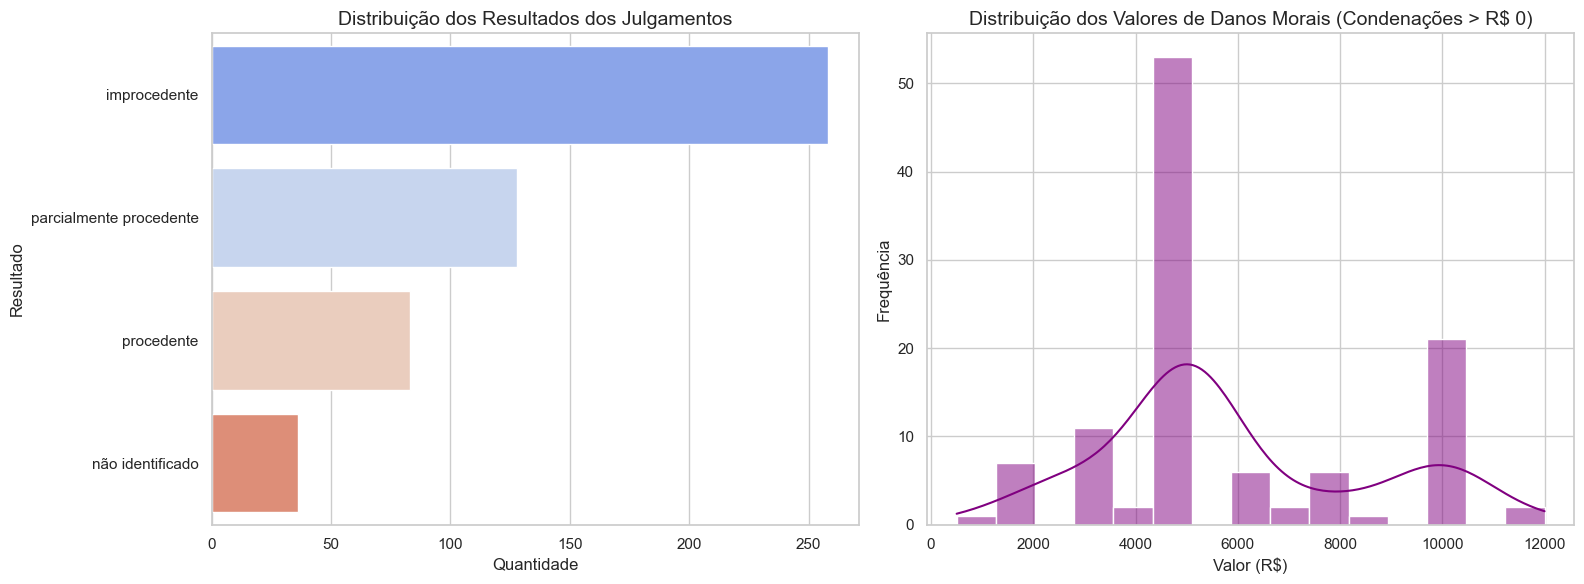

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Resultados
df_plot_res = df_clean[df_clean['resultado_julgamento_ia'] != 'outro']
# Resultados
sns.countplot(data=df_plot_res, y='resultado_julgamento_ia', 
              order=df_plot_res['resultado_julgamento_ia'].value_counts().index, 
              palette='coolwarm', ax=axes[0])
axes[0].set_title('Distribuição dos Resultados dos Julgamentos', fontsize=14)
axes[0].set_xlabel('Quantidade', fontsize=12)
axes[0].set_ylabel('Resultado', fontsize=12)

# Valores de Danos Morais (apenas > 0)
danos_morais_positivos = df_clean[df_clean['valor_danos_morais_ia'] > 0]
sns.histplot(danos_morais_positivos['valor_danos_morais_ia'], bins=15, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Distribuição dos Valores de Danos Morais (Condenações > R$ 0)', fontsize=14)
axes[1].set_xlabel('Valor (R$)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()


Distribuição Geográfica - Processos por Comarca

Visualização no mapa de São Paulo. Cada município é colorido de acordo com a quantidade de processos ou outra métrica selecionada.

Comarca: região da justiça estadual, geralmente correspondendo a um município.

In [91]:
# Carregar GeoJSON dos municípios de SP
with open(Path('geodata') / 'SP.json', 'r', encoding='utf-8') as f:
    sp_geojson = json.load(f)

# Normalizar nomes para matching
def _normalizar_nome_geo(nome):
    if pd.isna(nome): return ''
    t = unicodedata.normalize('NFKD', str(nome)).encode('ascii', 'ignore').decode('ascii')
    return t.strip().lower()

# Mapear nome do município -> GEOCODIGO
comarca_map = {}
for feat in sp_geojson['features']:
    comarca_map[_normalizar_nome_geo(feat['properties']['NOME'])] = feat['properties']['GEOCODIGO']

# Lista completa de todos os municípios de SP (base sempre desenhada)
sp_all_geocodigos = [feat['properties']['GEOCODIGO'] for feat in sp_geojson['features']]
sp_all_nomes = [feat['properties']['NOME'] for feat in sp_geojson['features']]

# Agregar por comarca
df_mapa = df_clean.groupby('comarca').agg(
    total_processos=('id_processo', 'count'),
    valor_medio_morais=('valor_danos_morais_ia', 'mean'),
).reset_index()

# Taxa de procedência
def _calc_taxa(g):
    total = len(g)
    if total == 0: return 0.0
    favoraveis = g['resultado_julgamento_ia'].isin(['procedente', 'parcialmente procedente']).sum()
    return (favoraveis / total) * 100

taxa = df_clean.groupby('comarca').apply(_calc_taxa, include_groups=False).reset_index()
taxa.columns = ['comarca', 'taxa_procedencia']
df_mapa = df_mapa.merge(taxa, on='comarca', how='left')

# Match comarca -> geocodigo
df_mapa['comarca_norm'] = df_mapa['comarca'].apply(_normalizar_nome_geo)
df_mapa['geocodigo'] = df_mapa['comarca_norm'].map(comarca_map)
df_mapa['valor_medio_morais'] = df_mapa['valor_medio_morais'].round(2)
df_mapa['taxa_procedencia'] = df_mapa['taxa_procedencia'].round(1)

# Estatísticas de match
matched = df_mapa['geocodigo'].notna().sum()
total_comarcas = len(df_mapa)
pct = matched / total_comarcas * 100
print(f'Comarcas mapeadas: {matched}/{total_comarcas} ({pct:.1f}%)')
if total_comarcas - matched > 0:
    sem_match = df_mapa[df_mapa['geocodigo'].isna()]['comarca'].tolist()
    print(f'Sem match ({total_comarcas - matched}):', sem_match)

df_plot = df_mapa[df_mapa['geocodigo'].notna()].copy()


def make_sp_choropleth(df, color_col, color_scale, title, value_label):
    # Camada 1 — base: todos os municípios de SP em cinza escuro neutro
    base = go.Choropleth(
        geojson=sp_geojson,
        locations=sp_all_geocodigos,
        featureidkey='properties.GEOCODIGO',
        z=[0] * len(sp_all_geocodigos),
        colorscale=[[0, '#1f2937'], [1, '#1f2937']],
        showscale=False,
        marker_line_color='rgba(255,255,255,0.35)',
        marker_line_width=0.4,
        hovertext=sp_all_nomes,
        hovertemplate='<b>%{hovertext}</b><br><i>sem processos</i><extra></extra>',
    )

    # Camada 2 — dados: municípios com valores na escala selecionada
    zmax_val = df[df[color_col] > 0][color_col].quantile(0.80) if color_col != 'taxa_procedencia' else df[df[color_col] > 0][color_col].quantile(0.85)
    data_layer = go.Choropleth(
        geojson=sp_geojson,
        locations=df['geocodigo'],
        featureidkey='properties.GEOCODIGO',
        z=df[color_col],
        zmax=zmax_val,
        colorscale=color_scale,
        marker_line_color='white',
        marker_line_width=0.9,
        customdata=df[['comarca', 'total_processos', 'valor_medio_morais', 'taxa_procedencia']].values,
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Processos: %{customdata[1]:,}<br>'
            'Danos morais médios: R$ %{customdata[2]:,.2f}<br>'
            'Procedência: %{customdata[3]:.1f}%'
            '<extra></extra>'
        ),
        colorbar=dict(title=value_label, thickness=14, len=0.75, outlinewidth=0),
    )

    fig = go.Figure(data=[base, data_layer])
    fig.update_geos(
        fitbounds='geojson',
        visible=False,
        projection_type='mercator',
        bgcolor='rgba(0,0,0,0)',
    )
    fig.update_layout(
        title=dict(text=title, x=0.02, xanchor='left'),
        margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
        height=620,
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
    )
    return fig


TypeError: Expected numeric dtype, got object instead.

In [ ]:
# Mapa 2: Valor médio de danos morais por comarca
fig2 = make_sp_choropleth(
    df_plot,
    color_col='valor_medio_morais',
    color_scale=[[0.0, '#2e1065'], [0.3, '#7e22ce'], [0.7, '#d946ef'], [1.0, '#fdf4ff']],
    title='Valor Médio de Danos Morais por Comarca — Estado de São Paulo',
    value_label='Valor Médio (R$)',
)
fig2.show()


In [ ]:
# Mapa 3: Taxa de procedência por comarca
fig3 = make_sp_choropleth(
    df_plot,
    color_col='taxa_procedencia',
    color_scale=[[0.0, '#022c22'], [0.3, '#059669'], [0.7, '#34d399'], [1.0, '#f0fdf4']],
    title='Taxa de Procedência por Comarca — Estado de São Paulo',
    value_label='Procedência (%)',
)
fig3.show()


Proporção de Contato Prévio

Qual é o percentual geral de processos em que o autor tentou resolver o problema antes de judicializar?

Judicializar: entrar com ação na justiça.

In [ ]:
plt.figure(figsize=(4, 6))
contagens = df_clean['contato_previo_banco_ia'].value_counts(normalize=True) * 100
nao_pct = contagens.get('não', 0)
sim_pct = contagens.get('sim', 0)

plt.bar(['Contato Prévio'], [nao_pct], color='#ef476f', label='Não')
plt.bar(['Contato Prévio'], [sim_pct], bottom=[nao_pct], color='#06d6a0', label='Sim')

# Setas e textos
plt.text(0, nao_pct/2, f'Não\n{nao_pct:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=12)
if sim_pct > 0:
    plt.ylim(0, 115)
    if sim_pct < 8:
        plt.annotate(f'Sim\n{sim_pct:.1f}%', xy=(0, nao_pct + sim_pct/2), xytext=(0.5, nao_pct + sim_pct + 5),
                     ha='center', va='bottom', color='black', fontweight='bold', fontsize=12,
                     arrowprops=dict(facecolor='black', arrowstyle='->', shrinkA=0, shrinkB=0))
    else:
        plt.text(0, nao_pct + sim_pct/2, f'Sim\n{sim_pct:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.title('Proporção de Contato Prévio', fontsize=14)
plt.axis('off')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


Parte 2: O Impacto do Contato Prévio

Análise focada na relação entre ter tido contato administrativo com o banco antes de processar e os resultados da ação.

Contato Prévio vs. Probabilidade de Vitória

Pergunta: Clientes que tentaram resolver o problema com o banco antes de processar têm taxa maior de vitória?

Taxa de procedência: percentual de processos em que o juiz deu razão para o cliente (julgamento procedente).

In [ ]:
contato_resultado = pd.crosstab(df_clean['contato_previo_banco_ia'], df_clean['resultado_julgamento_ia'], normalize='index') * 100

ax = contato_resultado.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Resultado do Julgamento por Contato Prévio (%)', fontsize=14)
plt.xlabel('Houve Contato Prévio?', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.legend(title='Resultado', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionar os valores nas barras
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)
    
plt.tight_layout()
plt.show()


Taxa de Vitória por Grupo de Contato Prévio

Tabela limpa com a taxa de vitória (procedente + parcialmente procedente) por grupo — para citar diretamente na defesa.

In [ ]:
# Tabela limpa: taxa de vitória por grupo de contato prévio
vit_tab = pd.crosstab(
    df_clean['contato_previo_banco_ia'],
    df_clean['resultado_julgamento_ia'],
    normalize='index'
) * 100

# Identifica colunas "favoráveis" dinamicamente
col_vit = [c for c in vit_tab.columns if 'procedente' in c.lower() and 'im' not in c.lower()]
vit_tab['taxa_vitoria (%)'] = vit_tab[col_vit].sum(axis=1)
vit_tab = vit_tab.round(1)

display(vit_tab.style.format("{:.1f}")
        .set_caption("Tabela: Resultado do Julgamento por Grupo de Contato Prévio (% por linha)"))

print("\nTaxa de vitória (procedente + parcialmente procedente):")
for grupo, taxa in vit_tab['taxa_vitoria (%)'].items():
    print(f"  {grupo}: {taxa:.1f}%")


Contato Prévio vs. Valores de Indenização

Pergunta: Quando há comprovação de contato prévio, os juízes determinam indenizações maiores por danos morais?

In [ ]:
plt.figure(figsize=(10, 6))
# Filtrar apenas quem ganhou danos morais
condenados_morais = df_clean[df_clean['valor_danos_morais_ia'] > 0]

sns.boxplot(data=condenados_morais, x='contato_previo_banco_ia', y='valor_danos_morais_ia', palette='Set3')
plt.title('Distribuição do Valor de Danos Morais por Contato Prévio (Apenas Condenações > 0)', fontsize=14)
plt.xlabel('Houve Contato Prévio?', fontsize=12)
plt.ylabel('Valor de Danos Morais (R$)', fontsize=12)
plt.show()

# Imprimir as médias
medias = condenados_morais.groupby('contato_previo_banco_ia')['valor_danos_morais_ia'].mean()
print("Média de Danos Morais (quando há condenação):")
print(medias)


Tipo de Ação vs. Contato Prévio

Pergunta: Quais tipos de ação apresentam maior volume de tentativa prévia de acordo?

Tipo de ação: categoria jurídica da ação (exemplo: ação de consumidor, de cobrança, etc).

In [ ]:
plt.figure(figsize=(10, 6))
tipo_contato = pd.crosstab(df_clean['tipo_acao_ia'], df_clean['contato_previo_banco_ia'], normalize='index') * 100

ax = tipo_contato.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Pastel1')
plt.title('Proporção de Contato Prévio por Tipo de Ação (%)', fontsize=14)
plt.xlabel('Tipo de Ação', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.legend(title='Houve Contato?', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)
    
plt.tight_layout()
plt.show()

Análise Específica: Fraude em Conta ou Cartão

Pergunta: Processos de fraude têm dinâmica diferente dos demais? O Itaú é especialmente exposto em ações de fraude — o padrão de contato prévio e os resultados são distintos?

In [ ]:
# Fraude em conta/cartão: comparativo exploratório
df_fraude_eda = df_clean.copy()
df_fraude_eda['fraude'] = df_fraude_eda['tipo_acao_ia'].str.lower().str.contains('fraude', na=False)
df_fraude_eda['vitoria'] = df_fraude_eda['resultado_julgamento_ia'].isin(
    ['procedente', 'parcialmente procedente']).astype(int)
df_fraude_eda['contato_sim'] = (df_fraude_eda['contato_previo_banco_ia'] == 'sim').astype(int)

n_fraude_eda = df_fraude_eda['fraude'].sum()
print(f"Processos de fraude em conta/cartão: {n_fraude_eda:,} de {len(df_fraude_eda):,} "
      f"({n_fraude_eda/len(df_fraude_eda)*100:.1f}%)\n")

# Tabela comparativa
tab_f = df_fraude_eda.groupby('fraude').agg(
    n=('vitoria', 'count'),
    taxa_vitoria=('vitoria', 'mean'),
    taxa_contato=('contato_sim', 'mean'),
    media_morais=('valor_danos_morais_ia', lambda x: x[x > 0].mean()),
)
tab_f['taxa_vitoria'] *= 100
tab_f['taxa_contato'] *= 100
tab_f.index = ['Demais ações', 'Fraude em conta/cartão']
tab_f.columns = ['N processos', 'Taxa vitória (%)', 'Taxa contato prévio (%)', 'Danos morais médios (R$)']

display(tab_f.style.format({
    'N processos': '{:,.0f}',
    'Taxa vitória (%)': '{:.1f}',
    'Taxa contato prévio (%)': '{:.1f}',
    'Danos morais médios (R$)': 'R$ {:,.0f}'
}).set_caption("Comparativo: Fraude em conta/cartão vs. demais tipos de ação"))

# Boxplot danos morais (sem outliers extremos)
cond_f = df_fraude_eda[df_fraude_eda['valor_danos_morais_ia'] > 0].copy()
q95    = cond_f['valor_danos_morais_ia'].quantile(0.95)
cond_f = cond_f[cond_f['valor_danos_morais_ia'] <= q95]
cond_f['Grupo'] = cond_f['fraude'].map({False: 'Demais ações', True: 'Fraude em conta/cartão'})

plt.figure(figsize=(9, 5))
sns.boxplot(data=cond_f, x='Grupo', y='valor_danos_morais_ia', palette='Set2')
plt.title('Danos Morais Concedidos: Fraude vs. Demais (até percentil 95)', fontsize=13)
plt.xlabel('')
plt.ylabel('Valor de Danos Morais (R$)', fontsize=11)
plt.tight_layout()
plt.show()


Atribuição de Culpa vs. Contato Prévio

Pergunta: Se houve contato prévio, o juiz atribui culpa com mais frequência ao banco?

In [ ]:
plt.figure(figsize=(10, 6))
culpa_contato = pd.crosstab(df_clean['culpa_atribuida_ia'], df_clean['contato_previo_banco_ia'], normalize='columns') * 100

ax = culpa_contato.T.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Distribuição de Culpa Atribuída de Acordo com Contato Prévio (%)', fontsize=14)
plt.xlabel('Houve Contato Prévio?', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.legend(title='Culpa Atribuída', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)
    
plt.tight_layout()
plt.show()

Boletim de Ocorrência vs. Probabilidade de Vitória

Pergunta: Fazer boletim de ocorrência (registro na polícia) aumenta a chance de vitória?

Boletim de ocorrência: documento formal que registra um crime ou fato delituoso na polícia.

In [ ]:
plt.figure(figsize=(10, 6))
bo_resultado = pd.crosstab(df_clean['boletim_de_ocorrencia_ia'], df_clean['resultado_julgamento_ia'], normalize='index') * 100

ax = bo_resultado.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Spectral')
plt.title('Resultado do Julgamento por Existência de B.O. (%)', fontsize=14)
plt.xlabel('Fez Boletim de Ocorrência?', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.legend(title='Resultado', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)
    
plt.tight_layout()
plt.show()

Parte 3: Análise por Canais de Contato

Foco nos processos em que conseguimos identificar qual canal foi usado para o cliente tentar contato com o banco: SAC, Procon, Reclame Aqui, etc.

Canais de Contato Mais Utilizados

Pergunta: Quando o cliente procura o banco, qual é o canal mais usado?

SAC: Serviço de Atendimento ao Consumidor.
Procon: Programa de Proteção e Defesa do Consumidor.
Reclame Aqui: plataforma online para reclamações de consumidores.

In [ ]:
canais = df_clean[df_clean['canal_contato_ia'] != "não identificado"]

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=canais, y='canal_contato_ia', order=canais['canal_contato_ia'].value_counts().index, palette='magma')
plt.title('Canais de Contato Prévio Mais Utilizados', fontsize=14)
plt.xlabel('Quantidade de Processos', fontsize=12)
plt.ylabel('Canal de Contato', fontsize=12)
plt.show()

Impacto do Canal de Contato no Resultado

Pergunta: Usar Procon/Reclame Aqui gera maior probabilidade de vitória do que usar o SAC?

In [ ]:
plt.figure(figsize=(10, 6))
canal_resultado = pd.crosstab(canais['canal_contato_ia'], canais['resultado_julgamento_ia'], normalize='index') * 100

sns.heatmap(canal_resultado, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Proporção (%)'})
plt.title('Probabilidade de Resultado por Canal de Contato Prévio', fontsize=14)
plt.ylabel('Canal de Contato', fontsize=12)
plt.xlabel('Resultado do Julgamento', fontsize=12)
plt.show()

Evolução Temporal do Contato Prévio

Pergunta: O padrão de contato prévio mudou ao longo do tempo? Há impacto visível pós-pandemia (mar/2020) ou pós-PIX (nov/2020)?

In [ ]:
import matplotlib.dates as mdates

df_temp = df_clean.copy()
df_temp['data_dt'] = pd.to_datetime(df_temp['data_disponibilizacao'], errors='coerce')
df_temp = df_temp.dropna(subset=['data_dt'])
df_temp['ano_mes'] = df_temp['data_dt'].dt.to_period('M')

mensal = df_temp.groupby('ano_mes').agg(
    n          = ('contato_previo_banco_ia', 'count'),
    n_contato  = ('contato_previo_banco_ia', lambda x: (x == 'sim').sum()),
    n_proced   = ('resultado_julgamento_ia',
                  lambda x: x.isin(['procedente', 'parcialmente procedente']).sum()),
    n_julgado  = ('resultado_julgamento_ia',
                  lambda x: x.isin(['procedente', 'parcialmente procedente', 'improcedente']).sum()),
).reset_index()

mensal['pct_contato']     = mensal['n_contato'] / mensal['n'] * 100
mensal['pct_procedencia'] = np.where(mensal['n_julgado'] > 0,
                                      mensal['n_proced'] / mensal['n_julgado'] * 100, np.nan)
mensal['data']            = mensal['ano_mes'].dt.to_timestamp()
mensal = mensal[mensal['n'] >= 10].reset_index(drop=True)
mensal['mm3_contato'] = mensal['pct_contato'].rolling(3, center=True, min_periods=2).mean()
mensal['mm3_proced']  = mensal['pct_procedencia'].rolling(3, center=True, min_periods=2).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.plot(mensal['data'], mensal['pct_contato'],  alpha=0.25, color='steelblue', lw=1)
ax1.plot(mensal['data'], mensal['mm3_contato'],  color='steelblue', lw=2, label='Média móvel 3m')
ax1.set_ylabel('% Processos com Contato Prévio', fontsize=12)
ax1.set_title('Evolução Temporal: Contato Prévio e Taxa de Procedência', fontsize=14)
ax1.legend(loc='upper right')

ax2.plot(mensal['data'], mensal['pct_procedencia'], alpha=0.25, color='darkorange', lw=1)
ax2.plot(mensal['data'], mensal['mm3_proced'],      color='darkorange', lw=2, label='Média móvel 3m')
ax2.set_ylabel('% Procedente (incl. parcialmente)', fontsize=12)
ax2.set_xlabel('Mês de Disponibilização', fontsize=12)
ax2.legend(loc='upper right')

data_min, data_max = mensal['data'].min(), mensal['data'].max()
eventos = [
    ('Pandemia (mar/2020)', pd.Timestamp('2020-03-01'), 'gray'),
    ('PIX (nov/2020)',      pd.Timestamp('2020-11-01'), 'seagreen'),
]
for ax in [ax1, ax2]:
    for label, ts, cor in eventos:
        if data_min <= ts <= data_max:
            ax.axvline(ts, color=cor, linestyle='--', alpha=0.7, lw=1.5, label=label)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f"Período: {mensal['data'].min().strftime('%Y-%m')} "
      f"a {mensal['data'].max().strftime('%Y-%m')} | {len(mensal)} meses com ≥10 processos")


Modelo Inferencial - Efeito do Contato Prévio com o Banco

Criamos modelos estatísticos para entender quais características dos casos estão associadas ao contato prévio com o banco.

Três modelos diferentes:

| Modelo | Pergunta | Abordagem |
|--------|----------|-----------|
| 1 | Quais características estão associadas ao contato prévio? | Regressão logística com todas as variáveis |
| 2 | Qual o efeito específico do contato sobre o resultado? | Modelo ajustado para evitar confusão de fatores |
| 3 | O efeito varia conforme o tipo de ação? | Análise separada por tipo de ação |

Regressão logística: método estatístico que permite entender como diferentes características influenciam um resultado sim/não.

Variável de confusão: fator que poderia influenciar o resultado, não apenas o contato prévio.

In [ ]:
# === Configuração da análise inferencial ===

RANDOM_STATE = 42

# Variáveis de interesse
VAR_TRATAMENTO = 'contato_previo_banco_ia'      # 'sim' / 'não'
NIVEL_BASE     = 'não'                           # referência para o coeficiente

# Controles do caso (não derivados da sentença)
CONTROLES_CASO = [
    'tipo_acao_ia',
    'rito_processual_ia',
    'boletim_de_ocorrencia_ia',
    'justica_gratuita_ia',
    'mencao_reclame_aqui_ia',
]

# Variáveis de alta cardinalidade — agrupadas (raras viram "outras")
ALTA_CARDIN = ['comarca', 'assunto']
MIN_FREQ_GRUPO = 200  # categorias com < N casos viram 'outras'

# Outcomes
OUTCOME_PROCED   = 'procedente'                 # binária derivada de resultado_julgamento_ia
OUTCOME_VL_MORAL = 'valor_danos_morais_ia'      # numérico (R$)


In [ ]:
# === Preparação do dataset inferencial ===
df_inf = df_clean.copy()

# 1) Tratamento: contato prévio em 'sim'/'não'
df_inf = df_inf[df_inf[VAR_TRATAMENTO].isin(['sim', 'não'])].copy()

# 2) Outcome A — procedência (vitória do autor): procedente ou parcialmente procedente = 1
def _proced(r):
    if r in ['procedente', 'parcialmente procedente']: return 1
    if r in ['improcedente']:                          return 0
    return np.nan  # extinto / não identificado: fora desse modelo

df_inf[OUTCOME_PROCED] = df_inf['resultado_julgamento_ia'].apply(_proced)

# 3) Outcome B — log do valor de danos morais (somente em casos com condenação > 0)
df_inf['ln_morais']    = np.where(
    df_inf[OUTCOME_VL_MORAL] > 0,
    np.log(df_inf[OUTCOME_VL_MORAL].fillna(0).astype(float)),
    np.nan,
)
df_inf['condenado_moral'] = (df_inf[OUTCOME_VL_MORAL] > 0).astype(int)

# 4) Categóricas — NaN explícito + agrupar raras
for col in CONTROLES_CASO + [VAR_TRATAMENTO]:
    df_inf[col] = df_inf[col].fillna('desconhecido').astype(str)

for col in ALTA_CARDIN:
    df_inf[col] = df_inf[col].fillna('desconhecido').astype(str)
    counts = df_inf[col].value_counts()
    freq   = counts[counts >= MIN_FREQ_GRUPO].index
    df_inf[f'{col}_grp'] = df_inf[col].where(df_inf[col].isin(freq), 'outras')

print(f'Linhas totais: {len(df_clean):,}')
print(f'Linhas com tratamento válido (sim/não): {len(df_inf):,}\n')

print('Outcome A — procedência (descartado extinto/não identificado):')
print(df_inf[OUTCOME_PROCED].value_counts(dropna=False).rename('n'))
print()
print('Outcome B — condenado em danos morais > 0:')
print(df_inf['condenado_moral'].value_counts().rename('n'))
print()
print(f'Comarcas distintas após agrupamento: {df_inf["comarca_grp"].nunique()}')
print(f'Assuntos distintos após agrupamento: {df_inf["assunto_grp"].nunique()}')


In [ ]:
# === Helpers para comparar especificações ===
def _termo_tratamento(modelo):
    for idx in modelo.params.index:
        if VAR_TRATAMENTO in idx and "[T.sim]" in idx:
            return idx
    return None

def resumo_termo(modelo, termo, exponentiate=False):
    """Coef, std err, p-value, IC 95% para um termo específico.

    Se exponentiate=True (Logit), retorna OR e IC do OR.
    """
    if termo not in modelo.params.index:
        return None
    coef    = modelo.params[termo]
    se      = modelo.bse[termo]
    p       = modelo.pvalues[termo]
    ci_low, ci_high = modelo.conf_int().loc[termo]
    out = {
        'coef':       coef,
        'std_err':    se,
        'p_value':    p,
        'CI95_low':   ci_low,
        'CI95_high':  ci_high,
        'n_obs':      int(modelo.nobs),
    }
    if exponentiate:
        out.update({
            'OR':         np.exp(coef),
            'OR_CI95_lo': np.exp(ci_low),
            'OR_CI95_hi': np.exp(ci_high),
        })
    return out


def tabela_specs(modelos_dict, termo, exponentiate=False):
    """Tabela comparando o mesmo termo em várias especificações."""
    rows = []
    for nome, m in modelos_dict.items():
        termo_real = _termo_tratamento(m)
        r = resumo_termo(m, termo_real, exponentiate=exponentiate)
        if r is None:
            continue
        rows.append({'spec': nome, **r})
    df = pd.DataFrame(rows).set_index('spec')
    return df.round(4)


def estrela(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return ''


In [ ]:
# === Modelo A — Logit em procedência ===
# H1: o contato prévio com o banco aumenta a probabilidade de o autor vencer?

df_a = df_inf.dropna(subset=[OUTCOME_PROCED]).copy()
df_a[OUTCOME_PROCED] = df_a[OUTCOME_PROCED].astype(int)

f_base    = f'{OUTCOME_PROCED} ~ C({VAR_TRATAMENTO}, Treatment("{NIVEL_BASE}"))'
f_controles = f_base + ' + ' + ' + '.join(f'C({c})' for c in CONTROLES_CASO)
f_completa  = f_controles + ' + C(comarca_grp) + C(assunto_grp)'

modelos_A = {
    '1_bivariado':  smf.logit(f_base,      data=df_a).fit(method='bfgs', maxiter=1000, disp=0),
    '2_controles':  smf.logit(f_controles, data=df_a).fit(method='bfgs', maxiter=1000, disp=0),
    '3_completo':   smf.logit(f_completa,  data=df_a).fit(method='bfgs', maxiter=1000, disp=0),
}

print('Modelo A — Logit em procedência (vitória do autor)')
print(f'n = {len(df_a):,}\n')

tab_A = tabela_specs(modelos_A, None, exponentiate=True)
print('Efeito do contato prévio (vs "não") em cada especificação:')
print(tab_A)
print()
print('Leitura: OR > 1 → contato prévio aumenta chance de procedência; OR < 1 → reduz.')
print('Significância: *** p<0.001 | ** p<0.01 | * p<0.05 | . p<0.10')


Modelo A com Interação: contato_previo × tipo_acao

Pergunta: O efeito do contato prévio varia por tipo de ação? Faz diferença contatar o banco em casos de revisão contratual versus fraude em conta?

In [ ]:
# === Modelo A com interação contato_previo × tipo_acao ===
df_a_int = df_inf.dropna(subset=[OUTCOME_PROCED]).copy()
df_a_int[OUTCOME_PROCED] = df_a_int[OUTCOME_PROCED].astype(int)

controles_sem_tipo = [c for c in CONTROLES_CASO if c != 'tipo_acao_ia']
f_inter = (
    f'{OUTCOME_PROCED} ~ C({VAR_TRATAMENTO}, Treatment("{NIVEL_BASE}")) * C(tipo_acao_ia)'
    + (' + ' + ' + '.join(f'C({c})' for c in controles_sem_tipo) if controles_sem_tipo else '')
    + ' + C(comarca_grp) + C(assunto_grp)'
)

try:
    modelo_inter = smf.logit(f_inter, data=df_a_int).fit(method='bfgs', maxiter=1500, disp=0)
    print('Modelo A com Interação — Logit em procedência')
    print(f'n = {len(df_a_int):,} | AIC = {modelo_inter.aic:.0f} | Pseudo-R² = {modelo_inter.prsquared:.4f}\n')

    # Efeito marginal médio (AME) por tipo_acao
    tipos_n  = df_a_int['tipo_acao_ia'].value_counts()
    tipos_ok = tipos_n[tipos_n >= 30].index.tolist()

    ames = []
    for tipo in tipos_ok:
        sub     = df_a_int[df_a_int['tipo_acao_ia'] == tipo].copy()
        sub_sim = sub.copy(); sub_sim[VAR_TRATAMENTO] = 'sim'
        sub_nao = sub.copy(); sub_nao[VAR_TRATAMENTO] = 'não'
        try:
            ame = (modelo_inter.predict(sub_sim).mean() - modelo_inter.predict(sub_nao).mean()) * 100
            ames.append({'tipo_acao': tipo, 'AME (p.p.)': round(ame, 2), 'n': len(sub)})
        except Exception:
            pass

    if ames:
        df_ames = pd.DataFrame(ames).sort_values('AME (p.p.)').reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(10, max(4, len(df_ames) * 0.45 + 1)))
        colors = ['#d73027' if v < 0 else '#4575b4' for v in df_ames['AME (p.p.)']]
        bars   = ax.barh(df_ames['tipo_acao'], df_ames['AME (p.p.)'], color=colors, edgecolor='white')
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('Efeito Marginal Médio (p.p.)\nP[vitória | contato=sim] − P[vitória | contato=não]',
                      fontsize=11)
        ax.set_title('Efeito do Contato Prévio por Tipo de Ação (AME)', fontsize=13)
        for bar, (_, row) in zip(bars, df_ames.iterrows()):
            offset = 0.2 if row['AME (p.p.)'] >= 0 else -0.2
            ha     = 'left' if row['AME (p.p.)'] >= 0 else 'right'
            ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
                    f"n={row['n']:,}", va='center', ha=ha, fontsize=8)
        plt.tight_layout()
        plt.show()
        print("\nEfeito marginal médio por tipo de ação (pontos percentuais):")
        print(df_ames.to_string(index=False))
except Exception as e:
    print(f"Modelo com interação não convergiu: {e}")
    print("Sugestão: tentar method='newton' ou reduzir categorias de tipo_acao_ia.")


In [ ]:
# === Modelo B — OLS em log(valor de danos morais), em condenados ===
# H2: entre quem é condenado em danos morais, o contato prévio muda o valor?

df_b = df_inf.dropna(subset=['ln_morais']).copy()

f_base      = f'ln_morais ~ C({VAR_TRATAMENTO}, Treatment("{NIVEL_BASE}"))'
f_controles = f_base + ' + ' + ' + '.join(f'C({c})' for c in CONTROLES_CASO)
f_completa  = f_controles + ' + C(comarca_grp) + C(assunto_grp)'

# HC3 = erros-padrão robustos a heterocedasticidade
modelos_B = {
    '1_bivariado':  smf.ols(f_base,      data=df_b).fit(cov_type='HC3'),
    '2_controles':  smf.ols(f_controles, data=df_b).fit(cov_type='HC3'),
    '3_completo':   smf.ols(f_completa,  data=df_b).fit(cov_type='HC3'),
}

print('Modelo B — OLS em log(valor de danos morais), somente condenações > 0')
print(f'n = {len(df_b):,}\n')

tab_B = tabela_specs(modelos_B, None, exponentiate=False)
print('Efeito do contato prévio (vs "não") em log(R$) em cada spec:')
print(tab_B)
print()
print('Leitura log-linear: % de mudança no valor ≈ (exp(coef) - 1) × 100.')


Modelo B' — Danos Materiais

Pergunta: O contato prévio também influencia o valor dos danos materiais? Até agora analisamos apenas os danos morais no Modelo B.

In [ ]:
# === Modelo B' — OLS em log(danos_materiais), em condenados ===
df_inf['ln_materiais']       = np.where(df_inf['valor_danos_materiais_ia'] > 0,
                                         np.log(df_inf['valor_danos_materiais_ia']
                                                .fillna(0).astype(float)), np.nan)
df_inf['condenado_material'] = (df_inf['valor_danos_materiais_ia'] > 0).astype(int)

df_bp = df_inf.dropna(subset=['ln_materiais']).copy()
print(f"Modelo B' — danos materiais | condenados: n={len(df_bp):,}\n")

if len(df_bp) < 30:
    print("Amostra insuficiente para OLS robusto. Estatísticas descritivas:")
    print(df_inf[df_inf['valor_danos_materiais_ia'] > 0]['valor_danos_materiais_ia'].describe())
else:
    f_base_bp      = f'ln_materiais ~ C({VAR_TRATAMENTO}, Treatment("{NIVEL_BASE}"))'
    f_controles_bp = f_base_bp + ' + ' + ' + '.join(f'C({c})' for c in CONTROLES_CASO)
    f_completa_bp  = f_controles_bp + ' + C(comarca_grp) + C(assunto_grp)'

    modelos_Bp = {
        '1_bivariado': smf.ols(f_base_bp,      data=df_bp).fit(cov_type='HC3'),
        '2_controles': smf.ols(f_controles_bp, data=df_bp).fit(cov_type='HC3'),
        '3_completo':  smf.ols(f_completa_bp,  data=df_bp).fit(cov_type='HC3'),
    }

    tab_Bp = tabela_specs(modelos_Bp, None, exponentiate=False)
    print("Efeito do contato prévio em log(R$) — danos materiais:")
    print(tab_Bp)
    print("\nLeitura: % de mudança no valor ≈ (exp(coef) − 1) × 100.")

    print("\n--- Comparativo Morais (B) vs. Materiais (B'), spec. 3 completa ---")
    for nome, mod in [("Danos Morais   (B) ", modelos_B['3_completo']),
                      ("Danos Materiais(B')", modelos_Bp['3_completo'])]:
        t = _termo_tratamento(mod)
        if t and t in mod.params.index:
            coef = mod.params[t]; p = mod.pvalues[t]
            pct  = (np.exp(coef) - 1) * 100
            sig  = estrela(p)
            print(f"  {nome}: {pct:+.1f}% no valor (coef={coef:.3f}, p={p:.3f}{sig}, n={int(mod.nobs):,})")


In [ ]:
# === Modelo C — Logit no contato prévio (perfil do caso) ===
# Qual o perfil de caso associado a ter havido contato prévio com o banco?

df_c = df_inf.copy()
df_c['contato_sim'] = (df_c[VAR_TRATAMENTO] == 'sim').astype(int)

# Aqui o contato é o OUTCOME — predito por características do caso
f_perfil = 'contato_sim ~ ' + ' + '.join(f'C({c})' for c in CONTROLES_CASO) + ' + C(comarca_grp) + C(assunto_grp)'
modelo_C = smf.logit(f_perfil, data=df_c).fit(method='bfgs', maxiter=1000, disp=0)

# Top termos por |z-score| (significância da associação)
def top_termos(modelo, k=20, exclui_intercepto=True):
    df = pd.DataFrame({
        'coef':    modelo.params,
        'OR':      np.exp(modelo.params),
        'std_err': modelo.bse,
        'z':       modelo.tvalues,
        'p_value': modelo.pvalues,
    })
    df['sig'] = df['p_value'].apply(estrela)
    df['|z|'] = df['z'].abs()
    if exclui_intercepto and 'Intercept' in df.index:
        df = df.drop(index='Intercept')
    return df.sort_values('|z|', ascending=False).head(k).drop(columns='|z|').round(4)

print(f'Modelo C — Logit em contato_previo (n = {int(modelo_C.nobs):,})')
print(f'Pseudo R² (McFadden) = {modelo_C.prsquared:.4f}\n')
print('Top 20 características associadas a ter havido contato prévio:')
print(top_termos(modelo_C, k=20))


Variação por Magistrado

Pergunta: Magistrados diferentes têm taxas de procedência estatisticamente diferentes? A coluna magistrado não foi usada nos modelos principais — essa variação pode ser relevante para contextualizar os resultados.

In [ ]:
# === Variância entre magistrados ===
# Nota: magistrado não entra nos modelos por endogeneidade (atribuição não é aleatória).
# A variância observada é real e merece contextualização.
from scipy import stats as scipy_stats

df_mag = df_inf.dropna(subset=[OUTCOME_PROCED]).copy()
df_mag[OUTCOME_PROCED] = df_mag[OUTCOME_PROCED].astype(int)

mag_counts = df_mag['magistrado'].value_counts()
mag_suf    = mag_counts[mag_counts >= 30].index
df_mag_fil = df_mag[df_mag['magistrado'].isin(mag_suf)]

print(f"Magistrados com ≥30 casos: {len(mag_suf)} de {df_mag['magistrado'].nunique()} únicos")
print(f"Processos cobertos: {len(df_mag_fil):,} de {len(df_mag):,} ({len(df_mag_fil)/len(df_mag)*100:.1f}%)\n")

if len(mag_suf) >= 5:
    taxa_mag = (df_mag_fil.groupby('magistrado')[OUTCOME_PROCED]
                .agg(['mean', 'count']).reset_index())
    taxa_mag.columns = ['magistrado', 'taxa_procedencia', 'n']
    taxa_mag['taxa_procedencia'] *= 100
    taxa_mag = taxa_mag.sort_values('taxa_procedencia').reset_index(drop=True)

    n_show  = min(15, len(taxa_mag))
    df_show = pd.concat([taxa_mag.head(n_show), taxa_mag.tail(n_show)]).drop_duplicates()
    df_show = df_show.sort_values('taxa_procedencia').reset_index(drop=True)

    media_g = taxa_mag['taxa_procedencia'].mean()
    fig, ax = plt.subplots(figsize=(10, max(5, len(df_show) * 0.35 + 1)))
    colors  = ['#d73027' if v < media_g else '#4575b4' for v in df_show['taxa_procedencia']]
    bars    = ax.barh(df_show['magistrado'], df_show['taxa_procedencia'],
                      color=colors, edgecolor='white')
    ax.axvline(media_g, color='black', linestyle='--', lw=1.5, label=f'Média geral ({media_g:.1f}%)')
    ax.set_xlabel('Taxa de Procedência (%)', fontsize=12)
    ax.set_title('Taxa de Procedência por Magistrado (top e bottom 15)', fontsize=13)
    ax.legend()
    for bar, (_, row) in zip(bars, df_show.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"n={row['n']:,}", va='center', fontsize=7)
    plt.tight_layout()
    plt.show()

    # Kruskal-Wallis
    grupos = [df_mag_fil[df_mag_fil['magistrado'] == m][OUTCOME_PROCED].values for m in mag_suf]
    stat, pval = scipy_stats.kruskal(*grupos)
    print(f"Kruskal-Wallis: H={stat:.2f}, p={pval:.4f}")
    if pval < 0.05:
        print("→ Diferença significativa entre magistrados (p<0.05).")
    else:
        print("→ Sem evidência de diferença significativa entre magistrados.")

    print(f"\nMenor taxa: {taxa_mag.iloc[0]['magistrado']} "
          f"({taxa_mag.iloc[0]['taxa_procedencia']:.1f}%, n={int(taxa_mag.iloc[0]['n'])})")
    print(f"Maior taxa: {taxa_mag.iloc[-1]['magistrado']} "
          f"({taxa_mag.iloc[-1]['taxa_procedencia']:.1f}%, n={int(taxa_mag.iloc[-1]['n'])})")
else:
    print("Magistrados insuficientes com ≥30 casos para análise comparativa.")
    print(mag_counts.head(20))


Modelo Restrito a Fraude em Conta ou Cartão

Pergunta: O efeito do contato prévio na probabilidade de procedência se mantém especificamente em casos de fraude? O OR da amostra geral pode mascarar diferenças entre tipos de ação.

In [ ]:
# === Modelo A — amostra restrita a fraude em conta/cartão ===
df_fraude_inf = df_inf[df_inf['tipo_acao_ia'].str.lower().str.contains('fraude', na=False)].copy()
df_fraude_inf = df_fraude_inf.dropna(subset=[OUTCOME_PROCED]).copy()
df_fraude_inf[OUTCOME_PROCED] = df_fraude_inf[OUTCOME_PROCED].astype(int)

n_fr           = len(df_fraude_inf)
pct_contato_fr = (df_fraude_inf[VAR_TRATAMENTO] == 'sim').mean() * 100
taxa_vic_fr    = df_fraude_inf[OUTCOME_PROCED].mean() * 100
print(f"Amostra fraude: n={n_fr:,} | contato prévio: {pct_contato_fr:.1f}% | taxa vitória: {taxa_vic_fr:.1f}%\n")

if n_fr >= 50:
    controles_fr = [c for c in CONTROLES_CASO if c != 'tipo_acao_ia']
    f_fr_bi = f'{OUTCOME_PROCED} ~ C({VAR_TRATAMENTO}, Treatment("{NIVEL_BASE}"))'
    f_fr_cx = (f_fr_bi + ' + ' + ' + '.join(f'C({c})' for c in controles_fr)
               if controles_fr else f_fr_bi)

    try:
        mod_fr_bi = smf.logit(f_fr_bi, data=df_fraude_inf).fit(method='bfgs', maxiter=1000, disp=0)
        mod_fr_cx = smf.logit(f_fr_cx, data=df_fraude_inf).fit(method='bfgs', maxiter=1000, disp=0)

        print("Efeito do contato prévio em fraude (Odds Ratio):")
        for nome, mod in [('Bivariado     ', mod_fr_bi), ('Com controles ', mod_fr_cx)]:
            t  = _termo_tratamento(mod)
            if t and t in mod.params.index:
                coef = mod.params[t]; ci = mod.conf_int().loc[t]; p = mod.pvalues[t]
                OR   = np.exp(coef); sig = estrela(p)
                print(f"  {nome}: OR={OR:.2f} [{np.exp(ci.iloc[0]):.2f}–{np.exp(ci.iloc[1]):.2f}], "
                      f"p={p:.3f}{sig}")

        t_g   = _termo_tratamento(modelos_A['1_bivariado'])
        OR_g  = np.exp(modelos_A['1_bivariado'].params[t_g])
        t_fr  = _termo_tratamento(mod_fr_bi)
        OR_fr = np.exp(mod_fr_bi.params[t_fr])
        print(f"\n  Geral (todos os tipos): OR={OR_g:.2f}")
        print(f"  → Em fraude o OR é {'maior' if OR_fr > OR_g else 'menor'} que o geral "
              f"({OR_fr:.2f} vs {OR_g:.2f})")
    except Exception as e:
        print(f"Modelo de fraude não convergiu: {e}")
else:
    print(f"Amostra insuficiente (n={n_fr} < 50) para modelo logístico robusto em fraude.")


In [ ]:
# === Resumo de hipóteses — leitura inferencial direta ===

def relato_logit(modelos, termo, label_h):
    m = modelos['3_completo']
    termo = _termo_tratamento(m)
    r = resumo_termo(m, termo, exponentiate=True)
    if r is None:
        print(f'[{label_h}] termo não encontrado.')
        return
    s = estrela(r['p_value'])
    direc = 'aumenta' if r['OR'] > 1 else 'reduz'
    print(f'[{label_h}]')
    print(f'  OR = {r["OR"]:.2f}  (IC 95%: {r["OR_CI95_lo"]:.2f} – {r["OR_CI95_hi"]:.2f})')
    print(f'  p-value = {r["p_value"]:.4f} {s}')
    print(f'  Leitura: ter feito contato prévio {direc} as chances do desfecho em {abs(r["OR"]-1)*100:.1f}%, mantendo demais variáveis constantes.')
    print(f'  n = {r["n_obs"]:,}')
    print()


def relato_ols(modelos, termo, label_h, unidade='valor'):
    m = modelos['3_completo']
    termo = _termo_tratamento(m)
    r = resumo_termo(m, termo, exponentiate=False)
    if r is None:
        print(f'[{label_h}] termo não encontrado.')
        return
    s = estrela(r['p_value'])
    pct = (np.exp(r['coef']) - 1) * 100
    pct_lo = (np.exp(r['CI95_low']) - 1) * 100
    pct_hi = (np.exp(r['CI95_high']) - 1) * 100
    direc = 'maior' if pct > 0 else 'menor'
    print(f'[{label_h}]')
    print(f'  coef (log) = {r["coef"]:.3f}  (IC 95%: {r["CI95_low"]:.3f} – {r["CI95_high"]:.3f})')
    print(f'  p-value = {r["p_value"]:.4f} {s}')
    print(f'  Leitura: ter feito contato prévio está associado a um {unidade} {abs(pct):.1f}% {direc}, mantendo demais variáveis constantes (IC 95%: {pct_lo:+.1f}% a {pct_hi:+.1f}%).')
    print(f'  n = {r["n_obs"]:,}')
    print()


print('=' * 70)
print('CONCLUSÕES DO MODELO INFERENCIAL')
print('=' * 70)
print()

print('Pergunta central do plano: características do caso e da sentença')
print('associadas a processos com contato prévio ao banco?\n')

relato_logit(modelos_A, None,
             'H1 — Contato prévio → probabilidade de procedência')
relato_ols(modelos_B, None,
           'H2 — Contato prévio → valor da condenação (danos morais)',
           unidade='valor de condenação')

# H3 — perfil: cite os termos mais associados (z-score)
print('[H3 — Perfil dos casos com contato prévio]')
print('  Top 5 características mais associadas (ranking por |z|):')
top5 = top_termos(modelo_C, k=5)
for idx, row in top5.iterrows():
    direc = '↑' if row['coef'] > 0 else '↓'
    print(f'    {direc} {idx:<60} OR={row["OR"]:.2f}  p={row["p_value"]:.4f} {row["sig"]}')


In [ ]:
m = modelos_A['3_completo']
params = m.params
conf_int = m.conf_int()
pvalues = m.pvalues

fatores = []
ors = []
lower = []
upper = []
colors = []

for var in params.index:
    if var == 'Intercept' or 'outras' in var or 'desconhecido' in var:
        continue
        
    nome = var.replace("C(contato_previo_banco_ia, Treatment('não'))[T.sim]", "Houve Contato Prévio")
    nome = re.sub(r'C\([^)]+\)\[T\.([^\]]+)\]', r'\1', nome)
    
    or_val = np.exp(params[var])
    or_low = np.exp(conf_int.loc[var, 0])
    or_high = np.exp(conf_int.loc[var, 1])
    
    fatores.append(nome)
    ors.append(or_val)
    lower.append(or_val - or_low)
    upper.append(or_high - or_val)
    
    if pvalues[var] < 0.05:
        colors.append('#06d6a0' if or_val > 1 else '#ef476f')
    else:
        colors.append('gray')

fig, ax = plt.subplots(figsize=(10, max(6, len(fatores)*0.4)))
y_pos = np.arange(len(fatores))

ax.errorbar(ors, y_pos, xerr=[lower, upper], fmt='none', ecolor='black', capsize=4, zorder=1)
ax.scatter(ors, y_pos, color=colors, s=100, zorder=2)
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, zorder=0)

ax.set_yticks(y_pos)
ax.set_yticklabels(fatores)
ax.set_xlabel('Odds Ratio (OR)')
ax.set_title('Modelo A: Impacto das Variáveis na Chance de Procedência (Odds Ratios)', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
m_b = modelos_B['3_completo']
params_b = m_b.params
conf_int_b = m_b.conf_int()
pvalues_b = m_b.pvalues

fatores_b = []
pcts = []
lower_b = []
upper_b = []
colors_b = []

for var in params_b.index:
    if var == 'Intercept' or 'outras' in var or 'desconhecido' in var:
        continue
        
    nome = var.replace("C(contato_previo_banco_ia, Treatment('não'))[T.sim]", "Houve Contato Prévio")
    nome = re.sub(r'C\([^)]+\)\[T\.([^\]]+)\]', r'\1', nome)
    
    pct_est = (np.exp(params_b[var]) - 1) * 100
    pct_low = (np.exp(conf_int_b.loc[var, 0]) - 1) * 100
    pct_high = (np.exp(conf_int_b.loc[var, 1]) - 1) * 100
    
    fatores_b.append(nome)
    pcts.append(pct_est)
    lower_b.append(pct_est - pct_low)
    upper_b.append(pct_high - pct_est)
    
    if pvalues_b[var] < 0.05:
        colors_b.append('#8b5cf6' if pct_est > 0 else '#f59e0b')
    else:
        colors_b.append('gray')

fig, ax = plt.subplots(figsize=(10, max(6, len(fatores_b)*0.4)))
y_pos = np.arange(len(fatores_b))

ax.errorbar(pcts, y_pos, xerr=[lower_b, upper_b], fmt='none', ecolor='black', capsize=4, zorder=1)
ax.scatter(pcts, y_pos, color=colors_b, s=100, zorder=2)
ax.axvline(x=0.0, color='red', linestyle='--', alpha=0.5, zorder=0)

ax.set_yticks(y_pos)
ax.set_yticklabels(fatores_b)
ax.set_xlabel('Variação Percentual (%) no Valor de Condenação')
ax.set_title('Modelo B: Impacto das Variáveis no Valor de Danos Morais', fontsize=14)

plt.tight_layout()
plt.show()